# ABR → synapse: comparison workflow

**Wide vs long (Stage 2)** — Stage 1 noise classifier on wide ABR features; Stage 2 wide or long synapse regression (long aggregates to animal × frequency).

**Strain** — optional `strain_binary` in Stage 2 numeric block only.

**SPL ablation** — even-int dB on long data before pivoting to wide (even-SPL pivot cells).

**Brad long features** — amplitude, slope, distance, variance, Wave I segment, and curvature columns are computed **after** resampling each 0–8 ms crop to LibT (median Liberman crop length), matching `utils.nn_stage2_data`.

This notebook keeps only code needed to build tables and the **master summary** at the end. Exploratory noise/synapse RF–XGB plots and duplicate Liberman intro cells were removed. Run all cells top to bottom; outputs are cleared on save.

**XGBoost:** `XGB_STAGE2_PARAM_GRID` and `NOISE_XGB_PARAM_GRID` (if you re-add auxiliary fits).


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

from utils.data_loader import load_data


In [2]:
from pathlib import Path

share_path = Path(".")


In [3]:
liberman_df = load_data(db_level=0)


In [4]:
peak_curvs = liberman_df["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = liberman_df["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
liberman_df = pd.concat([liberman_df, peak_curvs, trough_curvs], axis=1)


In [5]:
liberman_df = liberman_df.rename(
    columns={
        "Subject": "animal_id",
        "Frequency(kHz)": "frequency",
        "Level(dB)": "level",
        "Amplitude": "amplitude",
        "Slope": "slope",
        "Total Variance": "total_variance",
        "Distance": "distance",
        "Strain": "strain",
        "Strain (binary)": "strain_binary",
    }
)
liberman_df["noise_cat"] = [0 if x else 1 for x in (liberman_df["Noise"] <= 0.91)]


In [6]:
import importlib
import utils.nn_stage2_data
importlib.reload(utils.nn_stage2_data)

from utils.nn_stage2_data import (
    compute_full_wave_target_len,
    _apply_brad_libt_features,
    _build_brad_prefeature,
)

# Brad rows: merge IO + synapses only (native ``waveform``); features below are on LibT grid.
brad_prefeature = _build_brad_prefeature(share_path)

_lib_for_len = liberman_df.rename(columns={"Waveform": "full_waveform"})
tw_lib, _, _ = compute_full_wave_target_len(
    brad_prefeature,
    _lib_for_len,
    prefer_liberman_len=True,
)
brad_buran_df = _apply_brad_libt_features(brad_prefeature, tw_lib)

# Align curvature column names with Liberman long columns used elsewhere in this notebook.
brad_buran_df = brad_buran_df.rename(
    columns={
        "PeakIEarlyCurvature": "PeakILeftCurvature",
        "PeakICentralCurvature": "PeakIOverallCurvature",
        "PeakILateCurvature": "PeakIRightCurvature",
        "TroughIEarlyCurvature": "TroughILeftCurvature",
        "TroughICentralCurvature": "TroughIOverallCurvature",
        "TroughILateCurvature": "TroughIRightCurvature",
    }
)


In [7]:
import importlib
import utils.nn_stage2_data as _nn_data
importlib.reload(_nn_data)
from utils.nn_stage2_data import (
    MOUSE_SPLIT_RANDOM_STATE,
    STAGE_SPL_LEVELS,
    _noise_feats_from_wide,
    split_by_mouse,
    syn_feats_from_wide_common,
    wide_stage1_fit,
    wide_stage1_val,
)
from utils.nn_stage2 import attach_noise_preds_long, fit_stage1_wide_best


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    log_features,
    cat_features=[],
    minmax_features=[],
    target="synapses",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            # ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            # ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor


In [9]:
cols = [
    "amplitude",
    "slope",
    "distance",
    "total_variance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

reformatted = []

for col in cols:
    df = (
        brad_buran_df.pivot_table(
            index=["animal_id", "frequency"], columns="level", values=col
        )
        .rename_axis(columns="level_dB")
        .add_prefix(f"{col}_")
    )
    reformatted.append(df)
reformatted = pd.concat(reformatted, axis=1)

# Add Noise column
noise = brad_buran_df.groupby(["animal_id", "frequency"])["noise_cat"].mean()
synapses = brad_buran_df.groupby(["animal_id", "frequency"])["synapses"].mean()
groups = brad_buran_df.groupby(["animal_id", "frequency"])[["DataGroup"]].first()
exp_group = brad_buran_df.groupby(["animal_id", "frequency"])["tx"].first().rename(
    "experimental_group"
)

# Combine
reformatted = reformatted.join(noise).join(synapses).join(groups).join(exp_group)
if "strain_binary" in brad_buran_df.columns:
    _sb = brad_buran_df.groupby(["animal_id", "frequency"])["strain_binary"].first()
    reformatted = reformatted.join(_sb)

# fill NaNs with interpolated/extrapolated values:
for col in cols:
    amp_cols = [c for c in reformatted.columns if c.startswith(col)]
    reformatted[amp_cols] = reformatted[amp_cols].interpolate(
        axis=1, limit_direction="both"
    )
reformatted.reset_index(inplace=True)

# Even-int SPL long rows only, then pivot (matches noise_classifier_clean)
brad_buran_df_even = brad_buran_df[
    brad_buran_df["level"].round().astype(int) % 2 == 0
].copy()

reformatted_even = []
for col in cols:
    df = (
        brad_buran_df_even.pivot_table(
            index=["animal_id", "frequency"], columns="level", values=col
        )
        .rename_axis(columns="level_dB")
        .add_prefix(f"{col}_")
    )
    reformatted_even.append(df)
reformatted_even = pd.concat(reformatted_even, axis=1)

noise_ev = brad_buran_df_even.groupby(["animal_id", "frequency"])["noise_cat"].mean()
synapses_ev = brad_buran_df_even.groupby(["animal_id", "frequency"])["synapses"].mean()
groups_ev = brad_buran_df_even.groupby(["animal_id", "frequency"])[
    ["DataGroup"]
].first()
reformatted_even = reformatted_even.join(noise_ev).join(synapses_ev).join(groups_ev)
if "strain_binary" in brad_buran_df_even.columns:
    _sb_ev = brad_buran_df_even.groupby(["animal_id", "frequency"])[
        "strain_binary"
    ].first()
    reformatted_even = reformatted_even.join(_sb_ev)

for col in cols:
    amp_cols = [c for c in reformatted_even.columns if c.startswith(col)]
    reformatted_even[amp_cols] = reformatted_even[amp_cols].interpolate(
        axis=1, limit_direction="both"
    )
reformatted_even.reset_index(inplace=True)

reformatted.head(10)


,animal_id,frequency,amplitude_20.0,amplitude_25.0,amplitude_30.0,amplitude_35.0,amplitude_40.0,amplitude_45.0,amplitude_50.0,amplitude_55.0,...,TroughIRightCurvature_60.0,TroughIRightCurvature_65.0,TroughIRightCurvature_70.0,TroughIRightCurvature_75.0,TroughIRightCurvature_80.0,noise_cat,synapses,DataGroup,strain_binary,freq_gt_16khz
0,B002-1,5.7,0.365016,0.365016,0.365016,0.365016,0.365016,0.365016,0.365016,0.322681,...,0.861919,0.257949,0.761497,0.185487,0.053841,0.0,7.294118,Train,0.0,0.0
1,B002-1,8.0,0.629093,0.629093,0.629093,0.629093,0.629093,0.629093,0.629093,0.629093,...,0.160775,0.062249,2.987077,0.148070,0.062094,0.0,9.500000,Train,0.0,0.0
2,B002-1,11.3,0.576504,0.576504,0.576504,0.576504,0.588132,0.748090,0.779034,1.015132,...,0.254034,0.094724,0.376561,0.112346,0.297297,0.0,14.444444,Train,0.0,0.0
3,B002-1,16.0,0.206396,0.237438,0.285115,0.332793,0.380470,0.475786,0.840713,1.167822,...,0.088264,0.598168,0.002975,0.092015,0.024478,0.0,13.812500,Train,0.0,0.0
4,B002-1,22.6,0.391484,0.391484,0.391484,0.391484,0.391484,0.391484,0.391484,0.460175,...,1.240952,0.526973,0.151251,0.324914,0.031107,0.0,13.937500,Train,0.0,1.0
5,B002-1,32.0,0.376228,0.376228,0.376228,0.376228,0.376228,0.376228,0.239078,0.444805,...,0.664281,6.769874,0.409966,0.226286,0.080595,0.0,16.937500,Train,0.0,1.0
6,B002-1,45.3,0.518365,0.518365,0.518365,0.518365,0.518365,0.518365,0.518365,0.518365,...,0.456527,2.393404,0.522293,0.525068,0.359157,0.0,12.533333,Train,0.0,1.0
7,B002-2,5.7,0.283179,0.283179,0.283179,0.283179,0.283179,0.180326,0.437278,0.482902,...,1.276468,0.512610,0.117479,2.146680,0.000437,0.0,9.642857,Validate,0.0,0.0
8,B002-2,8.0,0.286015,0.286015,0.286015,0.286015,0.286015,0.286015,0.303440,0.727816,...,0.768569,0.445772,0.083312,0.288987,0.358832,0.0,10.785714,Validate,0.0,0.0
9,B002-2,11.3,0.542211,0.542211,0.542211,0.294561,0.585562,0.766486,0.792169,0.999472,...,0.177034,0.001738,0.419828,0.465911,0.062170,0.0,12.866667,Validate,0.0,0.0


In [10]:
num_features = []
cat_features = []
log_features = ["frequency"]
for col in [
    "total_variance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    log_features.extend(cols)

for col in ["amplitude", "slope", "distance"]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = reformatted["noise_cat"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from utils.nn_stage2 import RF_PARAMS, mk_log_pipe
from utils.subject_cv import fit_subject_search, train_only_frame

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("rf", RandomForestClassifier(random_state=1)),
    ]
)

_train_only = reformatted.loc[train_only_frame(reformatted).index]
X_tune = _train_only[num_features + cat_features + log_features].dropna()
y_tune = _train_only.loc[X_tune.index, "noise_cat"].round().astype(int)
X_test_only = reformatted[reformatted.DataGroup == "Test"][
    num_features + cat_features + log_features
].dropna()
y_test_only = reformatted.loc[X_test_only.index, "noise_cat"].round().astype(int)

rf_search = fit_subject_search(
    rf_pipeline,
    RF_PARAMS,
    _train_only,
    num_features + cat_features + log_features,
    "noise_cat",
    scoring="accuracy",
    prefer_stratified=True,
    strat_col="experimental_group",
    random_state=1,
    n_jobs=-1,
)
print(f"Best noise-clf params: {rf_search.best_params_}")
acc_test = rf_search.score(X_test_only, y_test_only)
print(
    f"Best noise-clf CV score: {rf_search.best_score_:.3f}, "
    f"accuracy on test set: {acc_test:.3f}"
)
noise_pred_model = rf_search.best_estimator_

Best noise-clf params: {'rf__n_estimators': 30, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best noise-clf CV score: 0.632, R2 on test set: 0.675


In [12]:
X = reformatted[num_features + cat_features + log_features]
reformatted["noise_preds"] = noise_pred_model.predict(X)


In [13]:
reformatted["noise_proba"] = noise_pred_model.predict_proba(X)[:, 1]


In [14]:
preds = reformatted.groupby(["animal_id"]).agg({"noise_proba": "mean"})
preds["noise_proba"] = np.where(preds > 0.5, 1, 0)
preds


,noise_proba
animal_id,
B002-1,0
B002-2,0
B002-3,0
B002-4,0
B006-1,0
B006-2,0
B011-2,1
B011-3,1
B012-11,1


In [15]:
preds["noise_preds"] = np.where(preds["noise_proba"] > 0.5, 1, 0)
preds_dict = preds["noise_preds"].to_dict()
preds_proba_dict = preds["noise_proba"].to_dict()
reformatted["agg_noise_proba"] = reformatted["animal_id"].replace(preds_proba_dict)
reformatted["noise_preds"] = reformatted["animal_id"].replace(preds_dict)
# Same animal-level noise feature for even-SPL wide rows (used by wide OLS full + Stage 2)
reformatted_even["noise_preds"] = reformatted_even["animal_id"].replace(preds_dict)


In [16]:
# Columns to pivot into wide format (same set used for `reformatted`)
_PIVOT_COLS = [
    "amplitude",
    "slope",
    "distance",
    "total_variance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

# Reload Liberman data as `liberman_df` (kept separate from Brad data)
liberman_df = load_data(db_level=0)
_orig = liberman_df.copy()

# Expand curvature arrays into individual columns (mirrors the processing at the top of the notebook)
_pk = _orig["PeakI Curvature"].apply(pd.Series)
_pk.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
_tr = _orig["TroughI Curvature"].apply(pd.Series)
_tr.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
_orig = pd.concat([_orig, _pk, _tr], axis=1)

# Noise category: Noise ≤ 0.91 → unexposed (0), else exposed (1)
_orig["noise_cat"] = [0 if x else 1 for x in (_orig["Noise"] <= 0.91)]

# Standardise column names to match joined_df convention
_orig = _orig.rename(
    columns={
        "Subject": "animal_id",
        "Frequency(kHz)": "frequency",
        "Level(dB)": "level",
        "Amplitude": "amplitude",
        "Slope": "slope",
        "Total Variance": "total_variance",
        "Distance": "distance",
        "SynapsesPerIHC": "synapses",
        "Strain (binary)": "strain_binary",
        "PeakI Left Curvature": "PeakILeftCurvature",
        "PeakI Overall Curvature": "PeakIOverallCurvature",
        "PeakI Right Curvature": "PeakIRightCurvature",
        "TroughI Left Curvature": "TroughILeftCurvature",
        "TroughI Overall Curvature": "TroughIOverallCurvature",
        "TroughI Right Curvature": "TroughIRightCurvature",
    }
)
_orig["level"] = _orig["level"].astype(float)
_orig["frequency"] = _orig["frequency"].astype(float)

_keep = [
    "animal_id",
    "frequency",
    "level",
    "amplitude",
    "slope",
    "total_variance",
    "distance",
    "synapses",
    "noise_cat",
    "Noise",  # raw SPL metadata for deck O2 (mean per animal×frequency); not renamed
    "Group",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]
if "strain_binary" in _orig.columns:
    _i = _keep.index("noise_cat") + 1
    _keep = _keep[:_i] + ["strain_binary"] + _keep[_i:]
_orig = _orig[_keep].dropna()

# Same animal-level holdout as noise_classifier_clean: stratify on Group
_orig = split_by_mouse(_orig, split_on="animal_id", stratify_on="Group", random_state=MOUSE_SPLIT_RANDOM_STATE)

print(
    f"Original liberman_df: "
    f"{_orig['animal_id'].nunique()} animals, {len(_orig)} rows"
)
print(f"  frequencies (kHz): {sorted(_orig['frequency'].unique())}")
print(f"  levels (dB):       {sorted(_orig['level'].unique())}")


Original liberman_df: 105 animals, 12187 rows
  frequencies (kHz): [8.0, 11.3, 16.0, 22.6, 32.0, 45.2]
  levels (dB):       [10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0]


In [17]:
# Create wide-format (pivoted by level) for the original data,
# mirroring the `reformatted` construction earlier in the notebook.
_dfs = [
    _orig.pivot_table(index=["animal_id", "frequency"], columns="level", values=col)
    .rename_axis(columns="level_dB")
    .add_prefix(f"{col}_")
    for col in _PIVOT_COLS
]
reformatted_orig = pd.concat(_dfs, axis=1)

# Attach noise_cat and synapses (averaged per animal × frequency)
reformatted_orig = reformatted_orig.join(
    _orig.groupby(["animal_id", "frequency"])["noise_cat"].mean()
).join(_orig.groupby(["animal_id", "frequency"])["synapses"].mean())
if "strain_binary" in _orig.columns:
    reformatted_orig = reformatted_orig.join(
        _orig.groupby(["animal_id", "frequency"])["strain_binary"].first()
    )

reformatted_orig = reformatted_orig.join(
    _orig.groupby(["animal_id", "frequency"])[["DataGroup"]].first()
)

# Interpolate missing dB levels (same strategy as in the notebook)
for col in _PIVOT_COLS:
    _cs = [c for c in reformatted_orig.columns if c.startswith(f"{col}_")]
    reformatted_orig[_cs] = reformatted_orig[_cs].interpolate(
        axis=1, limit_direction="both"
    )

reformatted_orig = reformatted_orig.reset_index().dropna()

print(
    f"reformatted_orig: {len(reformatted_orig)} rows × {reformatted_orig.shape[1]} cols"
)
print(
    f"  dB levels: "
    f"{sorted(float(c.split('_')[-1]) for c in reformatted_orig.columns if c.startswith('amplitude_'))}"
)

# Even-int SPL on long data, then pivot to wide (matches noise_classifier_clean)
_orig_even = _orig[_orig["level"].round().astype(int) % 2 == 0].copy()
_dfs_even = [
    _orig_even.pivot_table(
        index=["animal_id", "frequency"], columns="level", values=col
    )
    .rename_axis(columns="level_dB")
    .add_prefix(f"{col}_")
    for col in _PIVOT_COLS
]
reformatted_orig_even = pd.concat(_dfs_even, axis=1)
reformatted_orig_even = reformatted_orig_even.join(
    _orig_even.groupby(["animal_id", "frequency"])["noise_cat"].mean()
).join(_orig_even.groupby(["animal_id", "frequency"])["synapses"].mean())
if "strain_binary" in _orig_even.columns:
    reformatted_orig_even = reformatted_orig_even.join(
        _orig_even.groupby(["animal_id", "frequency"])["strain_binary"].first()
    )
reformatted_orig_even = reformatted_orig_even.join(
    _orig_even.groupby(["animal_id", "frequency"])[["DataGroup"]].first()
)
for col in _PIVOT_COLS:
    _cs = [c for c in reformatted_orig_even.columns if c.startswith(f"{col}_")]
    reformatted_orig_even[_cs] = reformatted_orig_even[_cs].interpolate(
        axis=1, limit_direction="both"
    )
reformatted_orig_even = reformatted_orig_even.reset_index().dropna()
print(
    f"reformatted_orig_even: {len(reformatted_orig_even)} rows × "
    f"{reformatted_orig_even.shape[1]} cols"
)


reformatted_orig: 616 rows × 157 cols
  dB levels: [10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0]
reformatted_orig_even: 616 rows × 87 cols


In [18]:
# Find the intersection of pivot-derived columns between the two wide-format DataFrames.
# Using only common columns guarantees all three scenarios share the exact same feature space.
_feat_joined = {
    c
    for c in reformatted.columns
    if any(c.startswith(f"{col}_") for col in _PIVOT_COLS)
}
_feat_orig = {
    c
    for c in reformatted_orig.columns
    if any(c.startswith(f"{col}_") for col in _PIVOT_COLS)
}
_COMMON = sorted(_feat_joined & _feat_orig)

_feat_joined_ev = {
    c
    for c in reformatted_even.columns
    if any(c.startswith(f"{col}_") for col in _PIVOT_COLS)
}
_feat_orig_ev = {
    c
    for c in reformatted_orig_even.columns
    if any(c.startswith(f"{col}_") for col in _PIVOT_COLS)
}
_COMMON_EVEN = sorted(_feat_joined_ev & _feat_orig_ev)

print(
    f"Feature cols: {len(_feat_joined)} in joined_df, "
    f"{len(_feat_orig)} in orig, {len(_COMMON)} in common"
)
if _COMMON != _COMMON_EVEN:
    print(
        f"Even-SPL wide — common feat cols: {len(_COMMON_EVEN)} "
    f"(from even-long → wide pivots, the even-SPL pivot cells)"
)


def _syn_feats_from_common(common_cols):
    return syn_feats_from_wide_common(common_cols, has_strain=False)


# ── Stage 1 (noise): never include strain_binary ─────────────────────────────
_NOISE_NUM, _NOISE_LOG = _noise_feats_from_wide(_COMMON)
_NOISE_NUM_BB, _NOISE_LOG_BB = _noise_feats_from_wide(reformatted.columns)
_NOISE_NUM_LIB, _NOISE_LOG_LIB = _noise_feats_from_wide(reformatted_orig.columns)

_NOISE_NUM_BB_EVEN, _NOISE_LOG_BB_EVEN = _noise_feats_from_wide(
    reformatted_even.columns
)
_NOISE_NUM_LIB_EVEN, _NOISE_LOG_LIB_EVEN = _noise_feats_from_wide(
    reformatted_orig_even.columns
)

# ── Stage 2 (synapse): optional strain in numeric block only ─────────────────
_SYN_NUM, _SYN_LOG, _SYN_CAT = _syn_feats_from_common(_COMMON)
_SYN_NUM_EVEN, _SYN_LOG_EVEN, _SYN_CAT_EVEN = _syn_feats_from_common(_COMMON_EVEN)

_HAS_STRAIN = (
    "strain_binary" in reformatted.columns
    and "strain_binary" in reformatted_orig.columns
    and "strain_binary" in _orig.columns
)
if _HAS_STRAIN:
    _SYN_NUM_STRAIN = _SYN_NUM + ["strain_binary"]
    _SYN_NUM_STRAIN_EVEN = _SYN_NUM_EVEN + ["strain_binary"]
else:
    _SYN_NUM_STRAIN = list(_SYN_NUM)
    _SYN_NUM_STRAIN_EVEN = list(_SYN_NUM_EVEN)

print(
    f"\nNoise clf (wide only, no strain):    {len(_NOISE_NUM)} num  + {len(_NOISE_LOG)} log"
)
print(
    f"Synapse reg:  {len(_SYN_NUM)} num  + {len(_SYN_CAT)} cat  + {len(_SYN_LOG)} log"
)
print(f"BB  noise feats: {len(_NOISE_NUM_BB):3d} num + {len(_NOISE_LOG_BB):3d} log")
print(f"Lib noise feats: {len(_NOISE_NUM_LIB):3d} num + {len(_NOISE_LOG_LIB):3d} log")
print(
    f"Common (fallback for mixed-scenario Stage 1): "
    f"{len(_NOISE_NUM):3d} num + {len(_NOISE_LOG):3d} log"
)
print(
    f"Even-int dB — BB noise: {len(_NOISE_NUM_BB_EVEN)} num + {len(_NOISE_LOG_BB_EVEN)} log | "
    f"Lib: {len(_NOISE_NUM_LIB_EVEN)} num + {len(_NOISE_LOG_LIB_EVEN)} log | "
    f"S2 syn: {len(_SYN_NUM_EVEN)} num + {len(_SYN_LOG_EVEN)} log"
)
print(f"strain_binary available for Stage 2 only: {_HAS_STRAIN}")

# Hyperparameter search space (shared across both stages)
_RF_PARAMS = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}


Feature cols: 130 in joined_df, 150 in orig, 130 in common
Even-SPL wide — common feat cols: 70 (from even-long → wide pivots, the even-SPL pivot cells)

Noise clf (wide only, no strain):    39 num  + 92 log
Synapse reg:  28 num  + 1 cat  + 64 log
BB  noise feats:  39 num +  92 log
Lib noise feats:  45 num + 106 log
Common (fallback for mixed-scenario Stage 1):  39 num +  92 log
Even-int dB — BB noise: 21 num + 50 log | Lib: 24 num + 57 log | S2 syn: 16 num + 36 log
strain_binary available for Stage 2 only: True


In [19]:
from utils.stage2_sklearn import run_two_stage_model


def _wide_rf_triple(
    train_A,
    train_B,
    train_C,
    test_df,
    noise_num,
    noise_log,
    *,
    headers=None,
    label_suffix="",
    **syn_kw,
):
    """Run two-stage wide RF for A/B/C; returns dict lab → (r2, rmse, y, yhat)."""
    out = {}
    for lab, tr in [("A", train_A), ("B", train_B), ("C", train_C)]:
        if headers and lab in headers:
            print(headers[lab])
        lbl = f"{lab}{label_suffix}" if label_suffix else lab
        out[lab] = run_two_stage_model(
            tr,
            test_df,
            lbl,
            noise_num=noise_num,
            noise_log=noise_log,
            **syn_kw,
        )
    return out

In [20]:
# Test set: always the Brad Buran's dataset test split
_test = reformatted[reformatted.DataGroup == "Test"].reset_index(drop=True)

# Three training sets
_train_A = reformatted[reformatted.DataGroup != "Test"].reset_index(drop=True)
_train_B = pd.concat([_train_A, reformatted_orig], ignore_index=True)
_train_C = reformatted_orig.reset_index(drop=True)
# Even-SPL wide scenario frames (for ablation vs all-dB wide models)
_bb_wide_train_ev = reformatted_even[reformatted_even.DataGroup != "Test"].reset_index(
    drop=True
)
_bb_wide_test_ev = reformatted_even[reformatted_even.DataGroup == "Test"].reset_index(
    drop=True
)
_test_ev = _bb_wide_test_ev
_train_A_ev = _bb_wide_train_ev
_train_B_ev = pd.concat(
    [_train_A_ev, reformatted_orig_even.reset_index(drop=True)], ignore_index=True
)
_train_C_ev = reformatted_orig_even.reset_index(drop=True)

print("=" * 70)
print("Cross-dataset synapse prediction on Brad Buran's dataset test set")
print("=" * 70)

# Stage 1 pool = Stage 2 train per scenario (A/B/C).

_HDR_BB = {
    "A": "\n[A] Train on Brad Buran's dataset only:",
    "B": "\n[B] Train on Brad Buran's + Liberman dataset:",
    "C": "\n[C] Train on Liberman dataset only:",
}
_mbb_rf = _wide_rf_triple(
    _train_A,
    _train_B,
    _train_C,
    _test,
    _NOISE_NUM_BB,
    _NOISE_LOG_BB,
    headers=_HDR_BB,
)
r2_A, rmse_A, y_A, yhat_A = _mbb_rf["A"]
r2_B, rmse_B, y_B, yhat_B = _mbb_rf["B"]
r2_C, rmse_C, y_C, yhat_C = _mbb_rf["C"]

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"  {'Scenario':<43} {'R²':>5} {'RMSE':>8}")
print("  " + "-" * 57)
for _n, _r2, _rm in [
    ("A: Brad Buran's dataset only", r2_A, rmse_A),
    ("B: Brad Buran's + Liberman dataset", r2_B, rmse_B),
    ("C: Liberman dataset only", r2_C, rmse_C),
]:
    print(f"  {_n:<43} {_r2:>5.3f} {_rm:>8.3f}")

Cross-dataset synapse prediction on Brad Buran's dataset test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 train: 283 rows | S2 train: 283 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.470, test R²: 0.493, RMSE: 3.381

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 train: 283 rows | S2 train: 899 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.182, test R²: 0.469, RMSE: 3.458

[C] Train on Liberman dataset only:
  [C]  S1 train: 283 rows | S2 train: 616 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.431, test R²: -0.436, RMSE: 5.688

  Scenario                                       R²     RMSE
  ---------------------------------------------------------
  A: Brad Buran's dataset only                0.493    3.381
  B: Brad Buran's + Liberman dataset    

In [21]:
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score

# Use the same Brad Buran's dataset train/test split as the RF comparison above
_ref_train = reformatted[reformatted.DataGroup != "Test"]
_ref_test = reformatted[reformatted.DataGroup == "Test"]

# ── OLS baseline: amplitude at 80 dB only ─────────────────────────────────────
_ols_base = smf.ols("synapses ~ Q('amplitude_80.0')", data=_ref_train).fit()
_p_base = _ols_base.predict(_ref_test)
r2_ols_base = r2_score(_ref_test["synapses"], _p_base)
rmse_ols_base = np.sqrt(np.mean((_ref_test["synapses"] - _p_base) ** 2))
print(
    f"OLS baseline (amplitude_80 only) — R²: {r2_ols_base:.3f}, RMSE: {rmse_ols_base:.3f}"
)

# ── OLS full: noise_preds + all ABR features ───────────────────────────────────
# Earlier, fitting the same formula on all rows of `reformatted` (including test)
# `reformatted` — including the test rows — which leaks test data into training
# and produces an optimistically low RMSE (~2.67).  Here we train on the
# training split only to obtain an honest out-of-sample estimate.
# The simple baseline (amplitude_80 only) is barely affected by this leakage
# because a one-feature linear model cannot memorise individual data points.
#
# noise_preds here is the animal-level aggregated prediction from the notebook's
# noise classifier from the exploratory RF block above, not the two-stage CV models.
_model_text = "synapses ~ C(noise_preds)"
for _f in num_features + log_features:
    _model_text += f" + Q('{_f}')"
_ols_full = smf.ols(_model_text, data=_ref_train).fit()
_p_full = _ols_full.predict(_ref_test)
r2_ols_full = r2_score(_ref_test["synapses"], _p_full)
rmse_ols_full = np.sqrt(np.mean((_ref_test["synapses"] - _p_full) ** 2))
print(
    f"OLS full (noise_preds + all features) — R²: {r2_ols_full:.3f}, RMSE: {rmse_ols_full:.3f}"
)

# ── Combined results table ─────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"  {'Model / Scenario':<48} {'R²':>5} {'RMSE':>8}")
print("  " + "-" * 63)
print("  Two-stage RF (tested on Brad Buran's dataset test split):")
for _n, _r2, _rm in [
    ("  A: Brad Buran's dataset only", r2_A, rmse_A),
    ("  B: Brad Buran's + Liberman dataset", r2_B, rmse_B),
    ("  C: Liberman dataset only", r2_C, rmse_C),
]:
    print(f"  {_n:<48} {_r2:>5.3f} {_rm:>8.3f}")
print("  Linear regression baselines (Brad Buran's dataset train only):")
for _n, _r2, _rm in [
    ("  OLS baseline (amplitude_80 only)", r2_ols_base, rmse_ols_base),
    ("  OLS full (noise_preds + all features)", r2_ols_full, rmse_ols_full),
]:
    print(f"  {_n:<48} {_r2:>5.3f} {_rm:>8.3f}")
print("=" * 70)


OLS baseline (amplitude_80 only) — R²: 0.374, RMSE: 3.756
OLS full (noise_preds + all features) — R²: 0.022, RMSE: 4.695

  Model / Scenario                                    R²     RMSE
  ---------------------------------------------------------------
  Two-stage RF (tested on Brad Buran's dataset test split):
    A: Brad Buran's dataset only                   0.493    3.381
    B: Brad Buran's + Liberman dataset             0.469    3.458
    C: Liberman dataset only                       -0.436    5.688
  Linear regression baselines (Brad Buran's dataset train only):
    OLS baseline (amplitude_80 only)               0.374    3.756
    OLS full (noise_preds + all features)          0.022    4.695


In [22]:
# Liberman train/test from split_by_mouse on the Liberman long table, then DataGroup on wide
_lib_train = reformatted_orig[reformatted_orig.DataGroup != "Test"].reset_index(
    drop=True
)
_lib_test = reformatted_orig[reformatted_orig.DataGroup == "Test"].reset_index(
    drop=True
)
print(
    f"Liberman train: {len(_lib_train)} rows ({_lib_train['animal_id'].nunique()} animals)"
)
print(
    f"Liberman test:  {len(_lib_test)} rows ({_lib_test['animal_id'].nunique()} animals)"
)

# ── Three training sets (same scenarios, now tested on Liberman) ──────────────
# Scenario A uses ALL of Brad Buran's dataset — no need to reserve a test split
# since there is zero overlap with the Liberman test animals.
_train_A_lib = reformatted.reset_index(drop=True)
_train_B_lib = pd.concat([_train_A_lib, _lib_train], ignore_index=True)
_train_C_lib = _lib_train


_lib_train_ev = reformatted_orig_even[
    reformatted_orig_even.DataGroup != "Test"
].reset_index(drop=True)
_lib_test_ev = reformatted_orig_even[
    reformatted_orig_even.DataGroup == "Test"
].reset_index(drop=True)

_train_A_lib_ev = reformatted_even.reset_index(drop=True)
_train_B_lib_ev = pd.concat([_train_A_lib_ev, _lib_train_ev], ignore_index=True)
_train_C_lib_ev = _lib_train_ev

print("\n" + "=" * 70)
print("Cross-dataset synapse prediction on Liberman dataset test set")
print("=" * 70)

# Stage 1 pool = Stage 2 train per scenario.

_mlib_rf = _wide_rf_triple(
    _train_A_lib,
    _train_B_lib,
    _train_C_lib,
    _lib_test,
    _NOISE_NUM_LIB,
    _NOISE_LOG_LIB,
    headers=_HDR_BB,
)
r2_A_lib, rmse_A_lib, y_A_lib, yhat_A_lib = _mlib_rf["A"]
r2_B_lib, rmse_B_lib, y_B_lib, yhat_B_lib = _mlib_rf["B"]
r2_C_lib, rmse_C_lib, y_C_lib, yhat_C_lib = _mlib_rf["C"]

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"  {'Scenario':<43} {'R²':>5} {'RMSE':>8}")
print("  " + "-" * 57)
for _n, _r2, _rm in [
    ("A: Brad Buran's dataset only", r2_A_lib, rmse_A_lib),
    ("B: Brad Buran's + Liberman dataset", r2_B_lib, rmse_B_lib),
    ("C: Liberman dataset only", r2_C_lib, rmse_C_lib),
]:
    print(f"  {_n:<43} {_r2:>5.3f} {_rm:>8.3f}")

Liberman train: 491 rows (84 animals)
Liberman test:  125 rows (21 animals)

Cross-dataset synapse prediction on Liberman dataset test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 train: 491 rows | S2 train: 360 rows
           Noise clf  — CV acc: 0.601 | animal-level test acc: 0.857, AUC: 0.891
           Synapse reg — CV R²: 0.468, test R²: 0.212, RMSE: 3.124

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 train: 491 rows | S2 train: 851 rows
           Noise clf  — CV acc: 0.601 | animal-level test acc: 0.857, AUC: 0.891
           Synapse reg — CV R²: 0.120, test R²: 0.465, RMSE: 2.574

[C] Train on Liberman dataset only:
  [C]  S1 train: 491 rows | S2 train: 491 rows
           Noise clf  — CV acc: 0.601 | animal-level test acc: 0.857, AUC: 0.891
           Synapse reg — CV R²: 0.381, test R²: 0.584, RMSE: 2.271

  Scenario                                       R²     RMSE
  ---------------------------------------------------------
  A: Brad Buran's dataset onl

In [23]:
# ── OLS baselines on Liberman test ────────────────────────────────────────────
# Both models are trained on Liberman train only and use _SYN_NUM + _SYN_LOG
# (the common 40–80 dB feature set) so the columns are guaranteed to exist in
# both splits.  noise_cat (ground truth) is used as the noise feature here
# rather than Stage-1 predictions, since these are single-stage baselines.

# OLS baseline: amplitude at highest common 80-dB level
_amp80_col = (
    "amplitude_80.0"
    if "amplitude_80.0" in _COMMON
    else next((c for c in sorted(_COMMON) if c.startswith("amplitude_8")), None)
)

_ols_base_lib = smf.ols(f"synapses ~ Q('{_amp80_col}')", data=_lib_train).fit()
_p_base_lib = _ols_base_lib.predict(_lib_test)
r2_ols_base_lib = r2_score(_lib_test["synapses"], _p_base_lib)
rmse_ols_base_lib = np.sqrt(np.mean((_lib_test["synapses"] - _p_base_lib) ** 2))
print(
    f"OLS baseline ({_amp80_col})   — R²: {r2_ols_base_lib:.3f}, RMSE: {rmse_ols_base_lib:.3f}"
)

# OLS full: noise_cat + all common 40–80 dB features
_lib_model_text = "synapses ~ C(noise_cat)"
for _f in _SYN_NUM + _SYN_LOG:
    _lib_model_text += f" + Q('{_f}')"
_ols_full_lib = smf.ols(_lib_model_text, data=_lib_train).fit()
_p_full_lib = _ols_full_lib.predict(_lib_test)
r2_ols_full_lib = r2_score(_lib_test["synapses"], _p_full_lib)
rmse_ols_full_lib = np.sqrt(np.mean((_lib_test["synapses"] - _p_full_lib) ** 2))
print(
    f"OLS full (noise_cat + all features)   — R²: {r2_ols_full_lib:.3f}, RMSE: {rmse_ols_full_lib:.3f}"
)

# OLS all-ABR no noise (deck **O1** mark 2): only _SYN_NUM + _SYN_LOG — excludes noise_cat,
# metadata Noise / target_90, and Stage‑1 noise_preds (not in this formula).
from pathlib import Path

_o1_feat_cols = list(_SYN_NUM) + list(_SYN_LOG)
_o1_abr_text = "synapses ~ " + " + ".join(f"Q('{c}')" for c in _o1_feat_cols)
_ols_abr_only_lib = smf.ols(_o1_abr_text, data=_lib_train).fit()
_p_abr_only_lib = _ols_abr_only_lib.predict(_lib_test)
r2_ols_abr_only_lib = r2_score(_lib_test["synapses"], _p_abr_only_lib)
rmse_ols_abr_only_lib = np.sqrt(np.mean((_lib_test["synapses"] - _p_abr_only_lib) ** 2))
print(
    f"OLS all-ABR (no noise cols) — R²: {r2_ols_abr_only_lib:.3f}, RMSE: {rmse_ols_abr_only_lib:.3f}"
)

_o1_cache = Path("figures/cache")
_o1_cache.mkdir(parents=True, exist_ok=True)
_o1_path = _o1_cache / "deck_o1_ols_two_marks_liberman.parquet"
pd.DataFrame(
    [
        {
            "mark": 1,
            "strip_label": "Amp @ 80 dB only",
            "predictor_note": f"single column {_amp80_col}",
            "scenario": "C",
            "r2": r2_ols_base_lib,
            "rmse": rmse_ols_base_lib,
        },
        {
            "mark": 2,
            "strip_label": "All ABR (no noise)",
            "predictor_note": f"{len(_o1_feat_cols)} SPL cols from _SYN_NUM+_SYN_LOG; no noise_cat / target_90 / noise_preds",
            "scenario": "C",
            "r2": r2_ols_abr_only_lib,
            "rmse": rmse_ols_abr_only_lib,
        },
    ]
).to_parquet(_o1_path, index=False)
print("Saved", _o1_path.resolve(), "(deck O1 two-mark export)")

# ── Deck **O2** — three noise predictors **alone** (Liberman train C → test) ───
from utils.nn_stage2 import attach_noise_preds_long, fit_stage1_wide_best

_o2_meta = _orig.groupby(["animal_id", "frequency"], as_index=False).agg(
    deck_noise_spl=("Noise", "mean"),
    target_bin=("noise_cat", "mean"),
)
_o2_meta["target_90"] = _o2_meta["target_bin"].round().astype(int)
_o2_meta = _o2_meta.drop(columns=["target_bin"])

_o2_train = _lib_train.merge(_o2_meta, on=["animal_id", "frequency"], how="left")
_o2_test = _lib_test.merge(_o2_meta, on=["animal_id", "frequency"], how="left")

_s1_o2 = fit_stage1_wide_best(
    wide_stage1_fit(_lib_train),
    wide_stage1_val(_lib_train),
    _lib_test,
    _NOISE_NUM_LIB,
    _NOISE_LOG_LIB,
    verbose=False,
)
_o2_train = attach_noise_preds_long(
    _o2_train, _s1_o2["animal_pred_non_test"], fallback_noise_cat=False, require_full_coverage=True
)
_o2_test = attach_noise_preds_long(
    _o2_test, _s1_o2["animal_pred_te"], fallback_noise_cat=False
)

_o2_noise_ols = smf.ols("synapses ~ Q('deck_noise_spl')", data=_o2_train).fit()
_o2_true_ols = smf.ols("synapses ~ C(target_90)", data=_o2_train).fit()
_o2_pred_ols = smf.ols("synapses ~ C(noise_preds)", data=_o2_train).fit()

_o2_mask = (
    _o2_test["deck_noise_spl"].notna()
    & _o2_test["target_90"].notna()
    & _o2_test["noise_preds"].notna()
)
_o2_te_s = _o2_test.loc[_o2_mask].copy()
if _o2_te_s.empty:
    raise RuntimeError(
        "O2: no Liberman test rows with deck_noise_spl, target_90, and noise_preds — "
        "check Stage‑1 wide RF + merges."
    )
_o2_p1s = _o2_noise_ols.predict(_o2_te_s)
_o2_p2s = _o2_true_ols.predict(_o2_te_s)
_o2_p3s = _o2_pred_ols.predict(_o2_te_s)
r2_o2_noise = r2_score(_o2_te_s["synapses"], _o2_p1s)
rmse_o2_noise = float(np.sqrt(np.mean((_o2_te_s["synapses"] - _o2_p1s) ** 2)))
r2_o2_true = r2_score(_o2_te_s["synapses"], _o2_p2s)
rmse_o2_true = float(np.sqrt(np.mean((_o2_te_s["synapses"] - _o2_p2s) ** 2)))
r2_o2_pred = r2_score(_o2_te_s["synapses"], _o2_p3s)
rmse_o2_pred = float(np.sqrt(np.mean((_o2_te_s["synapses"] - _o2_p3s) ** 2)))

print(
    f"O2 — Noise SPL only — R²: {r2_o2_noise:.3f}, RMSE: {rmse_o2_noise:.3f} "
    f"(n_test_rows={len(_o2_te_s)})"
)
print(f"O2 — True binary only — R²: {r2_o2_true:.3f}, RMSE: {rmse_o2_true:.3f}")
print(f"O2 — Predicted binary only — R²: {r2_o2_pred:.3f}, RMSE: {rmse_o2_pred:.3f}")

_o2_path = _o1_cache / "deck_o2_ols_three_noise_marks_liberman.parquet"
pd.DataFrame(
    [
        {
            "mark": 1,
            "strip_label": "Recorded Noise (SPL) only",
            "predictor_note": "mean Noise per animal×frequency; no ABR columns",
            "scenario": "C",
            "r2": r2_o2_noise,
            "rmse": rmse_o2_noise,
        },
        {
            "mark": 2,
            "strip_label": "True exposure binary only",
            "predictor_note": "C(target_90) with target_90 from noise_cat (Noise<=0.91→0); no ABR columns",
            "scenario": "C",
            "r2": r2_o2_true,
            "rmse": rmse_o2_true,
        },
        {
            "mark": 3,
            "strip_label": "Predicted exposure binary only",
            "predictor_note": "C(noise_preds) Stage‑1 wide RF (same wide ABR feats as IId); OLS uses this col only",
            "scenario": "C",
            "r2": r2_o2_pred,
            "rmse": rmse_o2_pred,
        },
    ]
).to_parquet(_o2_path, index=False)
print("Saved", _o2_path.resolve(), "(deck O2 three-mark export)")

# ── Deck **O3** — four-mark ladder (Liberman train C → Liberman test) ───────────
# Marks 1–3: same RMSE / R² as **O1** (marks 1–2, full Liberman test) and **O2**
# (mark 3 = predicted-binary-only on the O2 eval subset). Mark 4: shipped linear
# stack — C(noise_preds) + all engineered wide SPL columns (_SYN_NUM + _SYN_LOG).
_o3_p4_txt = "synapses ~ C(noise_preds)"
for _f in _SYN_NUM + _SYN_LOG:
    _o3_p4_txt += f" + Q('{_f}')"
_ols_o3_full = smf.ols(_o3_p4_txt, data=_o2_train).fit()
_o3_te4 = _o2_test.dropna(subset=["noise_preds"])
if _o3_te4.empty:
    raise RuntimeError("O3 mark 4: no Liberman test rows with noise_preds.")
_o3_p4_pred = _ols_o3_full.predict(_o3_te4)
r2_o3_full = r2_score(_o3_te4["synapses"], _o3_p4_pred)
rmse_o3_full = float(np.sqrt(np.mean((_o3_te4["synapses"] - _o3_p4_pred) ** 2)))
print(
    f"O3 — Full ABR + predicted binary — R²: {r2_o3_full:.3f}, RMSE: {rmse_o3_full:.3f} "
    f"(n_test_rows={len(_o3_te4)})"
)

_o3_path = _o1_cache / "deck_o3_ols_four_stack_marks_liberman.parquet"
pd.DataFrame(
    [
        {
            "mark": 1,
            "strip_label": "Amp @ 80 dB only",
            "predictor_note": f"same as O1 mark 1: Q('{_amp80_col}') only; full Liberman test",
            "scenario": "C",
            "r2": r2_ols_base_lib,
            "rmse": rmse_ols_base_lib,
        },
        {
            "mark": 2,
            "strip_label": "All ABR (no noise)",
            "predictor_note": "same as O1 mark 2: _SYN_NUM+_SYN_LOG only; full Liberman test",
            "scenario": "C",
            "r2": r2_ols_abr_only_lib,
            "rmse": rmse_ols_abr_only_lib,
        },
        {
            "mark": 3,
            "strip_label": "Predicted exposure binary only",
            "predictor_note": "same as O2 mark 3: C(noise_preds) only; n=test rows with metadata+preds",
            "scenario": "C",
            "r2": r2_o2_pred,
            "rmse": rmse_o2_pred,
        },
        {
            "mark": 4,
            "strip_label": "Full ABR + predicted binary",
            "predictor_note": "C(noise_preds)+all _SYN_NUM+_SYN_LOG; test rows with non-null noise_preds",
            "scenario": "C",
            "r2": r2_o3_full,
            "rmse": rmse_o3_full,
        },
    ]
).to_parquet(_o3_path, index=False)
print("Saved", _o3_path.resolve(), "(deck O3 four-mark export)")

# ── Combined results table ─────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"  {'Model / Scenario':<48} {'R²':>5} {'RMSE':>8}")
print("  " + "-" * 63)
print("  Two-stage RF (tested on Liberman dataset test split):")
for _n, _r2, _rm in [
    ("  A: Brad Buran's dataset only", r2_A_lib, rmse_A_lib),
    ("  B: Brad Buran's + Liberman dataset", r2_B_lib, rmse_B_lib),
    ("  C: Liberman dataset only", r2_C_lib, rmse_C_lib),
]:
    print(f"  {_n:<48} {_r2:>5.3f} {_rm:>8.3f}")
print("  Linear regression baselines (Liberman train only):")
for _n, _r2, _rm in [
    ("  OLS baseline (amplitude_80 only)", r2_ols_base_lib, rmse_ols_base_lib),
    ("  OLS full (noise_cat + all features)", r2_ols_full_lib, rmse_ols_full_lib),
    ("  OLS all-ABR (no noise cols)", r2_ols_abr_only_lib, rmse_ols_abr_only_lib),
    ("  OLS deck O2 — Noise SPL only", r2_o2_noise, rmse_o2_noise),
    ("  OLS deck O2 — true binary only", r2_o2_true, rmse_o2_true),
    ("  OLS deck O2 — predicted binary only", r2_o2_pred, rmse_o2_pred),
    ("  OLS deck O3 — full ABR + predicted binary", r2_o3_full, rmse_o3_full),
]:
    print(f"  {_n:<48} {_r2:>5.3f} {_rm:>8.3f}")
print("=" * 70)

OLS baseline (amplitude_80.0)   — R²: 0.229, RMSE: 3.090
OLS full (noise_cat + all features)   — R²: 0.483, RMSE: 2.529
OLS all-ABR (no noise cols) — R²: 0.347, RMSE: 2.843
Saved /Users/nowaki027/MSDS/Practicum/figures/cache/deck_o1_ols_two_marks_liberman.parquet (deck O1 two-mark export)
O2 — Noise SPL only — R²: 0.104, RMSE: 3.331 (n_test_rows=125)
O2 — True binary only — R²: 0.233, RMSE: 3.081
O2 — Predicted binary only — R²: 0.163, RMSE: 3.219
Saved /Users/nowaki027/MSDS/Practicum/figures/cache/deck_o2_ols_three_noise_marks_liberman.parquet (deck O2 three-mark export)
O3 — Full ABR + predicted binary — R²: 0.408, RMSE: 2.708 (n_test_rows=125)
Saved /Users/nowaki027/MSDS/Practicum/figures/cache/deck_o3_ols_four_stack_marks_liberman.parquet (deck O3 four-mark export)

  Model / Scenario                                    R²     RMSE
  ---------------------------------------------------------------
  Two-stage RF (tested on Liberman dataset test split):
    A: Brad Buran's dataset onl

In [24]:
# Stage 1 summary: run abr_stage1_wide.ipynb (exports figures/cache/stage1_wide_metrics.json)


BB   wide  train / test :  283 /   77 rows
BB   long  train / test : 2811 /  743 rows
Lib  wide  train / test :  491 /  125 rows
Lib  long  train / test : 9751 / 2436 rows
Stage 1 noise RF — wide-format ABR features only (no strain_binary)

  Dataset                CV acc   Test acc   Test AUC
  --------------------------------------------------------------------
  Brad Buran's (wide)     0.629      0.750      1.000
  Liberman (wide)         0.601      0.857      0.891


In [25]:
from sklearn.metrics import r2_score as _r2_score

from utils.stage2_sklearn import run_two_stage_long_s2

In [26]:
_bb_long_all = brad_buran_df.reset_index(drop=True)  # all Brad Buran's long
_lib_long_all = _orig.reset_index(drop=True)  # all Liberman long

_LONG_S2_HDR = (
    "\n[A] Train on Brad Buran's dataset only:",
    "\n[B] Train on Brad Buran's + Liberman dataset:",
    "\n[C] Train on Liberman dataset only:",
)


def _bb_long_s2_rows():
    return [
        (
            _bb_wide_train,
            _bb_wide_test,
            _bb_long_train,
            _bb_long_test,
            _NOISE_NUM_BB,
            _NOISE_LOG_BB,
        ),
        (
            pd.concat([_bb_wide_train, reformatted_orig], ignore_index=True),
            _bb_wide_test,
            pd.concat([_bb_long_train, _lib_long_train]), ignore_index=True),
            _bb_long_test,
            _NOISE_NUM,
            _NOISE_LOG,
        ),
        (
            reformatted_orig.reset_index(drop=True),
            _bb_wide_test,
            _lib_long_train,
            _bb_long_test,
            _NOISE_NUM_LIB,
            _NOISE_LOG_LIB,
        ),
    ]


def _lib_long_s2_rows():
    return [
        (
            reformatted.reset_index(drop=True),
            _lib_test,
            _bb_long_train,
            _lib_long_test,
            _NOISE_NUM_BB,
            _NOISE_LOG_BB,
        ),
        (
            pd.concat([reformatted.reset_index(drop=True), _lib_train], ignore_index=True),
            _lib_test,
            pd.concat([_bb_long_train, _lib_long_train]), ignore_index=True),
            _lib_long_test,
            _NOISE_NUM,
            _NOISE_LOG,
        ),
        (
            _lib_train,
            _lib_test,
            _lib_long_train,
            _lib_long_test,
            _NOISE_NUM_LIB,
            _NOISE_LOG_LIB,
        ),
    ]


def _long_s2_triple_print(runner, six_rows, long_kw=None, *, label_suffix=""):
    if long_kw is None:
        long_kw = {}
    out = {}
    for lab, row, hdr in zip("ABC", six_rows, _LONG_S2_HDR):
        print(hdr)
        wt, wte, lt, lte, nn, nl = row
        lbl = f"{lab}{label_suffix}" if label_suffix else lab
        out[lab] = runner(wt, wte, lt, lte, lbl, noise_num=nn, noise_log=nl, **long_kw)
    return out


# ── Two-stage (long Stage 2) — Brad Buran's test set ─────────────────────────
print("=" * 70)
print("Two-stage (long Stage 2) — Brad Buran's dataset test set")
print("=" * 70)

_mbb_ls2 = _long_s2_triple_print(run_two_stage_long_s2, _bb_long_s2_rows())
r2_A_ls2_bb, rmse_A_ls2_bb = _mbb_ls2["A"]
r2_B_ls2_bb, rmse_B_ls2_bb = _mbb_ls2["B"]
r2_C_ls2_bb, rmse_C_ls2_bb = _mbb_ls2["C"]

# ── Two-stage (long Stage 2) — Liberman test set ─────────────────────────────
print("\n" + "=" * 70)
print("Two-stage (long Stage 2) — Liberman dataset test set")
print("=" * 70)

_mlib_ls2 = _long_s2_triple_print(
    run_two_stage_long_s2, _lib_long_s2_rows()
)
r2_A_ls2_lib, rmse_A_ls2_lib = _mlib_ls2["A"]
r2_B_ls2_lib, rmse_B_ls2_lib = _mlib_ls2["B"]
r2_C_ls2_lib, rmse_C_ls2_lib = _mlib_ls2["C"]

# Wide vs long: see master comparison cell at notebook end.

Two-stage (long Stage 2) — Brad Buran's dataset test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 wide train: 283 | long train: 2811 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.569, test R²: 0.566, RMSE: 3.128

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 wide train: 283 | long train: 14998 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.348, test R²: 0.231, RMSE: 4.161

[C] Train on Liberman dataset only:
  [C]  S1 wide train: 283 | long train: 12187 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.401, test R²: -0.357, RMSE: 5.530

Two-stage (long Stage 2) — Liberman dataset test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 wide train: 491 | long train: 3554 rows
           Noise clf  — CV acc: 0.601 | animal-level test acc: 0.857, AUC: 0

In [27]:
from utils.stage2_sklearn import (
    XGB_N_JOBS,
    XGB_STAGE2_PARAM_GRID,
    run_two_stage_long_s2_xgb,
    wide_xgb_triple,
)

# Alias for notebook cells that call _wide_xgb_triple
_wide_xgb_triple = wide_xgb_triple

In [28]:
# ── OLS baselines on long format ──────────────────────────────────────────────
print("=" * 70)
print("OLS baselines — long format (predictions aggregated per animal × freq)")
print("=" * 70)

print("\nBrad Buran's dataset (long train → long test):")
r2_ols_base_bb_l, rmse_ols_base_bb_l = eval_ols_long(
    _bb_long_train,
    _bb_long_test,
    _long_base_f,
    _LONG_OLS_BASE_COLS,
    "OLS baseline (amplitude only)",
)
r2_ols_full_bb_l, rmse_ols_full_bb_l = eval_ols_long(
    _bb_long_train,
    _bb_long_test,
    _long_full_f,
    _LONG_OLS_FULL_COLS,
    "OLS full (noise_cat + all feats)",
)

print("\nLiberman dataset (long train → long test):")
r2_ols_base_lib_l, rmse_ols_base_lib_l = eval_ols_long(
    _lib_long_train,
    _lib_long_test,
    _long_base_f,
    _LONG_OLS_BASE_COLS,
    "OLS baseline (amplitude only)",
)
r2_ols_full_lib_l, rmse_ols_full_lib_l = eval_ols_long(
    _lib_long_train,
    _lib_long_test,
    _long_full_f,
    _LONG_OLS_FULL_COLS,
    "OLS full (noise_cat + all feats)",
)

# ── XGBoost two-stage — Brad Buran's test set ─────────────────────────────────
print("\n" + "=" * 70)
print("XGBoost two-stage (long Stage 2) — Brad Buran's dataset test set")
print("=" * 70)

_mbb_xl = _long_s2_triple_print(
    run_two_stage_long_s2_xgb, _bb_long_s2_rows()
)
r2_A_xgb_bb, rmse_A_xgb_bb = _mbb_xl["A"]
r2_B_xgb_bb, rmse_B_xgb_bb = _mbb_xl["B"]
r2_C_xgb_bb, rmse_C_xgb_bb = _mbb_xl["C"]

# ── XGBoost two-stage — Liberman test set ─────────────────────────────────────
print("\n" + "=" * 70)
print("XGBoost two-stage (long Stage 2) — Liberman dataset test set")
print("=" * 70)

_mlib_xl = _long_s2_triple_print(
    run_two_stage_long_s2_xgb, _lib_long_s2_rows()
)
r2_A_xgb_lib, rmse_A_xgb_lib = _mlib_xl["A"]
r2_B_xgb_lib, rmse_B_xgb_lib = _mlib_xl["B"]
r2_C_xgb_lib, rmse_C_xgb_lib = _mlib_xl["C"]

# ── XGBoost two-stage — wide Stage 2 (no strain) ─────────────────────────────
print("\n" + "=" * 70)
print("XGBoost two-stage (wide Stage 2) — Brad Buran's dataset test set")
print("=" * 70)

_mbb_xw = _wide_xgb_triple(
    _train_A, _train_B, _train_C, _test, _NOISE_NUM_BB, _NOISE_LOG_BB
)
r2_A_xgbw_bb, rmse_A_xgbw_bb = _mbb_xw["A"]
r2_B_xgbw_bb, rmse_B_xgbw_bb = _mbb_xw["B"]
r2_C_xgbw_bb, rmse_C_xgbw_bb = _mbb_xw["C"]

print("\n" + "=" * 70)
print("XGBoost two-stage (wide Stage 2) — Liberman dataset test set")
print("=" * 70)

_mlib_xw = _wide_xgb_triple(
    _train_A_lib,
    _train_B_lib,
    _train_C_lib,
    _lib_test,
    _s1_lib,
    _NOISE_NUM_LIB,
    _NOISE_LOG_LIB,
)
r2_A_xgbw_lib, rmse_A_xgbw_lib = _mlib_xw["A"]
r2_B_xgbw_lib, rmse_B_xgbw_lib = _mlib_xw["B"]
r2_C_xgbw_lib, rmse_C_xgbw_lib = _mlib_xw["C"]

# Aliases for strain ablation cells (baseline wide XGB)
r2_A_xw, rmse_A_xw = r2_A_xgbw_bb, rmse_A_xgbw_bb
r2_B_xw, rmse_B_xw = r2_B_xgbw_bb, rmse_B_xgbw_bb
r2_C_xw, rmse_C_xw = r2_C_xgbw_bb, rmse_C_xgbw_bb
r2_A_lib_xw, rmse_A_lib_xw = r2_A_xgbw_lib, rmse_A_xgbw_lib
r2_B_lib_xw, rmse_B_lib_xw = r2_B_xgbw_lib, rmse_B_xgbw_lib
r2_C_lib_xw, rmse_C_lib_xw = r2_C_xgbw_lib, rmse_C_xgbw_lib


# Extended R²/RMSE grids replaced by master comparison cell at end of notebook.

OLS baselines — long format (predictions aggregated per animal × freq)

Brad Buran's dataset (long train → long test):
  OLS baseline (amplitude only)            R²=0.179  RMSE=4.300
  OLS full (noise_cat + all feats)         R²=0.532  RMSE=3.248

Liberman dataset (long train → long test):
  OLS baseline (amplitude only)            R²=-0.019  RMSE=3.701
  OLS full (noise_cat + all feats)         R²=0.344  RMSE=2.969

XGBoost two-stage (long Stage 2) — Brad Buran's dataset test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 wide train: 283 | long train: 2811 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg (XGB) — CV R²: 0.596, test R²: 0.572, RMSE: 3.106

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 wide train: 283 | long train: 14998 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg (XGB) — CV R²: 0.354, test R²: 0.281, RMSE: 4.024

[C] Train on Lib

## `strain_binary` feature ablation (Stage 2 only)

`strain_binary` is added to the **synapse** regressor numeric block only. Stage 1 noise models use the same wide ABR features as in the feature-definition block (no strain). Run prior comparison cells first so `_train_*`, `_test`, `_lib_*`, and long splits exist.


In [29]:
if not _HAS_STRAIN:
    print(
        "strain_binary unavailable on all of: reformatted, reformatted_orig, _orig — see the feature-definition block."
    )
else:
    _long_full_f_st = (
        "synapses ~ C(noise_cat) + C(strain_binary) + amplitude + slope + distance"
        " + level + total_variance + Q('frequency')"
    )
    _LONG_OLS_FULL_ST_COLS = list(_LONG_OLS_FULL_COLS) + ["strain_binary"]

    _kw_syn_st = {
        "syn_num": _SYN_NUM_STRAIN,
        "syn_cat": _SYN_CAT,
        "syn_log": _SYN_LOG,
    }
    _kw_long_st = {
        "long_num": _LONG_NUM_STRAIN,
        "long_cat": _LONG_CAT,
        "long_log": _LONG_LOG,
    }

    # ── RF wide Stage 2 — Brad Buran's test ────────────────────────────────────
    print("=" * 72)
    print("WITH strain_binary — two-stage RF, Brad Buran's dataset test set")
    print("=" * 72)
    _m_bb_st = _wide_rf_triple(
        _train_A,
        _train_B,
        _train_C,
        _test,
        _NOISE_NUM_BB,
        _NOISE_LOG_BB,
        label_suffix="+st",
        **_kw_syn_st,
    )
    r2_A_st, rmse_A_st, _, _ = _m_bb_st["A"]
    r2_B_st, rmse_B_st, _, _ = _m_bb_st["B"]
    r2_C_st, rmse_C_st, _, _ = _m_bb_st["C"]

    # ── RF wide Stage 2 — Liberman test ────────────────────────────────────────
    print("\n" + "=" * 72)
    print("WITH strain_binary — two-stage RF, Liberman dataset test set")
    print("=" * 72)
    _m_lib_st = _wide_rf_triple(
        _train_A_lib,
        _train_B_lib,
        _train_C_lib,
        _lib_test,
        _s1_lib,
        _NOISE_NUM_LIB,
        _NOISE_LOG_LIB,
        label_suffix="+st",
        **_kw_syn_st,
    )
    r2_A_lib_st, rmse_A_lib_st, _, _ = _m_lib_st["A"]
    r2_B_lib_st, rmse_B_lib_st, _, _ = _m_lib_st["B"]
    r2_C_lib_st, rmse_C_lib_st, _, _ = _m_lib_st["C"]

    # ── Long Stage 2 RF — Brad & Lib tests ─────────────────────────────────────
    print("\n" + "=" * 72)
    print("WITH strain_binary — long Stage 2 RF")
    print("=" * 72)
    _mbb_ls2_st = _long_s2_triple_print(
        run_two_stage_long_s2,
        _bb_long_s2_rows(),
        _kw_long_st,
        label_suffix="+st",
    )
    r2_A_ls2_bb_st, rmse_A_ls2_bb_st = _mbb_ls2_st["A"]
    r2_B_ls2_bb_st, rmse_B_ls2_bb_st = _mbb_ls2_st["B"]
    r2_C_ls2_bb_st, rmse_C_ls2_bb_st = _mbb_ls2_st["C"]
    _mlib_ls2_st = _long_s2_triple_print(
        run_two_stage_long_s2,
        _lib_long_s2_rows(),
        _kw_long_st,
        label_suffix="+st",
    )
    r2_A_ls2_lib_st, rmse_A_ls2_lib_st = _mlib_ls2_st["A"]
    r2_B_ls2_lib_st, rmse_B_ls2_lib_st = _mlib_ls2_st["B"]
    r2_C_ls2_lib_st, rmse_C_ls2_lib_st = _mlib_ls2_st["C"]

    # ── Long Stage 2 XGB ───────────────────────────────────────────────────────
    print("\n" + "=" * 72)
    print("WITH strain_binary — long Stage 2 XGB")
    print("=" * 72)
    _mbb_xl_st = _long_s2_triple_print(
        run_two_stage_long_s2_xgb,
        _bb_long_s2_rows(),
        _kw_long_st,
        label_suffix="+st",
    )
    r2_A_xbb_st, rmse_A_xbb_st = _mbb_xl_st["A"]
    r2_B_xbb_st, rmse_B_xbb_st = _mbb_xl_st["B"]
    r2_C_xbb_st, rmse_C_xbb_st = _mbb_xl_st["C"]
    _mlib_xl_st = _long_s2_triple_print(
        run_two_stage_long_s2_xgb,
        _lib_long_s2_rows(),
        _kw_long_st,
        label_suffix="+st",
    )
    r2_A_xlib_st, rmse_A_xlib_st = _mlib_xl_st["A"]
    r2_B_xlib_st, rmse_B_xlib_st = _mlib_xl_st["B"]
    r2_C_xlib_st, rmse_C_xlib_st = _mlib_xl_st["C"]

    # ── Long OLS full with strain_binary ─────────────────────────────────────────
    print("\n" + "=" * 72)
    print("WITH strain_binary — OLS full (long, aggregated)")
    print("=" * 72)
    r2_ols_full_bb_l_st, rmse_ols_full_bb_l_st = eval_ols_long(
        _bb_long_train,
        _bb_long_test,
        _long_full_f_st,
        _LONG_OLS_FULL_ST_COLS,
        "BB OLS full + strain_binary",
    )
    r2_ols_full_lib_l_st, rmse_ols_full_lib_l_st = eval_ols_long(
        _lib_long_train,
        _lib_long_test,
        _long_full_f_st,
        _LONG_OLS_FULL_ST_COLS,
        "Lib OLS full + strain_binary",
    )

    # ── Δ tables: with_strain − baseline (from earlier cells) ─────────────────────
    _HΔ = f"  {'Scenario':<40} {'ΔR² wide':>9} {'ΔRMSE wide':>11} {'ΔR² long':>9} {'ΔRMSE long':>11} {'ΔR² XGB':>9} {'ΔRMSE XGB':>11}"
    _DΔ = "  " + "-" * 98

    def _pr_bb():
        print("\n" + "=" * 102)
        print("  strain_binary ablation — Brad Buran's test set  (with − without)")
        print(_DΔ)
        print(_HΔ)
        print(_DΔ)
        for _n, _r0, _m0, _rl0, _ml0, _rx0, _mx0, _r1, _m1, _rl1, _ml1, _rx1, _mx1 in [
            (
                "A",
                r2_A,
                rmse_A,
                r2_A_ls2_bb,
                rmse_A_ls2_bb,
                r2_A_xgb_bb,
                rmse_A_xgb_bb,
                r2_A_st,
                rmse_A_st,
                r2_A_ls2_bb_st,
                rmse_A_ls2_bb_st,
                r2_A_xbb_st,
                rmse_A_xbb_st,
            ),
            (
                "B",
                r2_B,
                rmse_B,
                r2_B_ls2_bb,
                rmse_B_ls2_bb,
                r2_B_xgb_bb,
                rmse_B_xgb_bb,
                r2_B_st,
                rmse_B_st,
                r2_B_ls2_bb_st,
                rmse_B_ls2_bb_st,
                r2_B_xbb_st,
                rmse_B_xbb_st,
            ),
            (
                "C",
                r2_C,
                rmse_C,
                r2_C_ls2_bb,
                rmse_C_ls2_bb,
                r2_C_xgb_bb,
                rmse_C_xgb_bb,
                r2_C_st,
                rmse_C_st,
                r2_C_ls2_bb_st,
                rmse_C_ls2_bb_st,
                r2_C_xbb_st,
                rmse_C_xbb_st,
            ),
        ]:
            print(
                f"  {_n:<40} {_r1 - _r0:>+9.3f} {_m1 - _m0:>+11.3f} "
                f"{_rl1 - _rl0:>+9.3f} {_ml1 - _ml0:>+11.3f} "
                f"{_rx1 - _rx0:>+9.3f} {_mx1 - _mx0:>+11.3f}"
            )
        print("=" * 102)

    def _pr_lib():
        print("\n" + "=" * 102)
        print("  strain_binary ablation — Liberman test set  (with − without)")
        print(_DΔ)
        print(_HΔ)
        print(_DΔ)
        for _n, _r0, _m0, _rl0, _ml0, _rx0, _mx0, _r1, _m1, _rl1, _ml1, _rx1, _mx1 in [
            (
                "A",
                r2_A_lib,
                rmse_A_lib,
                r2_A_ls2_lib,
                rmse_A_ls2_lib,
                r2_A_xgb_lib,
                rmse_A_xgb_lib,
                r2_A_lib_st,
                rmse_A_lib_st,
                r2_A_ls2_lib_st,
                rmse_A_ls2_lib_st,
                r2_A_xlib_st,
                rmse_A_xlib_st,
            ),
            (
                "B",
                r2_B_lib,
                rmse_B_lib,
                r2_B_ls2_lib,
                rmse_B_ls2_lib,
                r2_B_xgb_lib,
                rmse_B_xgb_lib,
                r2_B_lib_st,
                rmse_B_lib_st,
                r2_B_ls2_lib_st,
                rmse_B_ls2_lib_st,
                r2_B_xlib_st,
                rmse_B_xlib_st,
            ),
            (
                "C",
                r2_C_lib,
                rmse_C_lib,
                r2_C_ls2_lib,
                rmse_C_ls2_lib,
                r2_C_xgb_lib,
                rmse_C_xgb_lib,
                r2_C_lib_st,
                rmse_C_lib_st,
                r2_C_ls2_lib_st,
                rmse_C_ls2_lib_st,
                r2_C_xlib_st,
                rmse_C_xlib_st,
            ),
        ]:
            print(
                f"  {_n:<40} {_r1 - _r0:>+9.3f} {_m1 - _m0:>+11.3f} "
                f"{_rl1 - _rl0:>+9.3f} {_ml1 - _ml0:>+11.3f} "
                f"{_rx1 - _rx0:>+9.3f} {_mx1 - _mx0:>+11.3f}"
            )
        print("=" * 102)

    _pr_bb()
    _pr_lib()


WITH strain_binary — two-stage RF, Brad Buran's dataset test set
  [A+st]  S1 train: 283 rows | S2 train: 283 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.466, test R²: 0.492, RMSE: 3.383
  [B+st]  S1 train: 283 rows | S2 train: 899 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.244, test R²: 0.487, RMSE: 3.399
  [C+st]  S1 train: 283 rows | S2 train: 616 rows
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse reg — CV R²: 0.436, test R²: -0.279, RMSE: 5.368

WITH strain_binary — two-stage RF, Liberman dataset test set
  [A+st]  S1 train: 491 rows | S2 train: 360 rows
           Noise clf  — CV acc: 0.601 | animal-level test acc: 0.857, AUC: 0.891
           Synapse reg — CV R²: 0.459, test R²: 0.180, RMSE: 3.187
  [B+st]  S1 train: 491 rows | S2 train: 851 rows
           Noise clf  — CV acc

In [30]:
# ── Wide-format add-on: OLS + wide XGB with strain_binary ─────────────────
# Baseline wide XGB (w/o strain) is computed in the extended comparison cell (`r2_*_xgbw_*`, aliases `r2_*_xw`).
if not _HAS_STRAIN:
    print("strain_binary unavailable on all required wide tables — skip wide add-on.")
else:

    # OLS wide with strain
    _ols_wide_full_st = "synapses ~ C(noise_cat) + C(strain_binary)"
    for _f in _SYN_NUM + _SYN_LOG:
        _ols_wide_full_st += f" + Q('{_f}')"
    _ols_bb_st = smf.ols(_ols_wide_full_st, data=_ref_train).fit()
    _p_bb_st = _ols_bb_st.predict(_ref_test)
    r2_ols_full_bb_w_st = r2_score(_ref_test["synapses"], _p_bb_st)
    rmse_ols_full_bb_w_st = np.sqrt(np.mean((_ref_test["synapses"] - _p_bb_st) ** 2))

    _ols_lib_full_st = "synapses ~ C(noise_cat) + C(strain_binary)"
    for _f in _SYN_NUM + _SYN_LOG:
        _ols_lib_full_st += f" + Q('{_f}')"
    _ols_lib_st = smf.ols(_ols_lib_full_st, data=_lib_train).fit()
    _p_lib_st = _ols_lib_st.predict(_lib_test)
    r2_ols_full_lib_w_st = r2_score(_lib_test["synapses"], _p_lib_st)
    rmse_ols_full_lib_w_st = np.sqrt(np.mean((_lib_test["synapses"] - _p_lib_st) ** 2))

    _xgb_kw_st = {
        "syn_num": _SYN_NUM_STRAIN,
        "syn_cat": _SYN_CAT,
        "syn_log": _SYN_LOG,
    }

    print("\n" + "=" * 76)
    print("Wide XGB two-stage (with strain_binary)")
    print("=" * 76)
    _mbb_xw_st = _wide_xgb_triple(
        _train_A,
        _train_B,
        _train_C,
        _test,
        _NOISE_NUM_BB,
        _NOISE_LOG_BB,
        label_suffix="+st",
        **_xgb_kw_st,
    )
    r2_A_xw_st, rmse_A_xw_st = _mbb_xw_st["A"]
    r2_B_xw_st, rmse_B_xw_st = _mbb_xw_st["B"]
    r2_C_xw_st, rmse_C_xw_st = _mbb_xw_st["C"]
    _mlib_xw_st = _wide_xgb_triple(
        _train_A_lib,
        _train_B_lib,
        _train_C_lib,
        _lib_test,
        _s1_lib,
        _NOISE_NUM_LIB,
        _NOISE_LOG_LIB,
        label_suffix="+st",
        **_xgb_kw_st,
    )
    r2_A_lib_xw_st, rmse_A_lib_xw_st = _mlib_xw_st["A"]
    r2_B_lib_xw_st, rmse_B_lib_xw_st = _mlib_xw_st["B"]
    r2_C_lib_xw_st, rmse_C_lib_xw_st = _mlib_xw_st["C"]

    # Wide-only delta table (with - without)
    print("\n" + "=" * 108)
    print(
        "  Wide-format strain ablation (with − without) — RF wide / XGB wide / OLS wide"
    )
    print("  " + "-" * 106)
    print(
        f"  {'Test set / Scenario':<32} {'ΔR² RF-wide':>12} {'ΔRMSE RF-wide':>14} {'ΔR² XGB-wide':>13} {'ΔRMSE XGB-wide':>15}"
    )
    print("  " + "-" * 106)
    for _name, _r0, _m0, _r1, _m1, _x0, _xm0, _x1, _xm1 in [
        (
            "Brad A",
            r2_A,
            rmse_A,
            r2_A_st,
            rmse_A_st,
            r2_A_xw,
            rmse_A_xw,
            r2_A_xw_st,
            rmse_A_xw_st,
        ),
        (
            "Brad B",
            r2_B,
            rmse_B,
            r2_B_st,
            rmse_B_st,
            r2_B_xw,
            rmse_B_xw,
            r2_B_xw_st,
            rmse_B_xw_st,
        ),
        (
            "Brad C",
            r2_C,
            rmse_C,
            r2_C_st,
            rmse_C_st,
            r2_C_xw,
            rmse_C_xw,
            r2_C_xw_st,
            rmse_C_xw_st,
        ),
        (
            "Lib  A",
            r2_A_lib,
            rmse_A_lib,
            r2_A_lib_st,
            rmse_A_lib_st,
            r2_A_lib_xw,
            rmse_A_lib_xw,
            r2_A_lib_xw_st,
            rmse_A_lib_xw_st,
        ),
        (
            "Lib  B",
            r2_B_lib,
            rmse_B_lib,
            r2_B_lib_st,
            rmse_B_lib_st,
            r2_B_lib_xw,
            rmse_B_lib_xw,
            r2_B_lib_xw_st,
            rmse_B_lib_xw_st,
        ),
        (
            "Lib  C",
            r2_C_lib,
            rmse_C_lib,
            r2_C_lib_st,
            rmse_C_lib_st,
            r2_C_lib_xw,
            rmse_C_lib_xw,
            r2_C_lib_xw_st,
            rmse_C_lib_xw_st,
        ),
    ]:
        print(
            f"  {_name:<32} {_r1 - _r0:>+12.3f} {_m1 - _m0:>+14.3f} {_x1 - _x0:>+13.3f} {_xm1 - _xm0:>+15.3f}"
        )
    print("  " + "-" * 106)
    print(
        f"  {'OLS wide full (+strain) on Brad':<32} {r2_ols_full_bb_w_st - r2_ols_full:>+12.3f} {rmse_ols_full_bb_w_st - rmse_ols_full:>+14.3f}"
    )
    print(
        f"  {'OLS wide full (+strain) on Lib':<32} {r2_ols_full_lib_w_st - r2_ols_full_lib:>+12.3f} {rmse_ols_full_lib_w_st - rmse_ols_full_lib:>+14.3f}"
    )
    print("=" * 108)


Wide XGB two-stage (with strain_binary)
  [A+st] XGB-wide — CV R²: 0.513, test R²: 0.491, RMSE: 3.386
  [B+st] XGB-wide — CV R²: 0.372, test R²: 0.554, RMSE: 3.169
  [C+st] XGB-wide — CV R²: 0.460, test R²: -0.184, RMSE: 5.165
  [A+st] XGB-wide — CV R²: 0.475, test R²: 0.151, RMSE: 3.242
  [B+st] XGB-wide — CV R²: 0.348, test R²: 0.558, RMSE: 2.340
  [C+st] XGB-wide — CV R²: 0.424, test R²: 0.621, RMSE: 2.165

  Wide-format strain ablation (with − without) — RF wide / XGB wide / OLS wide
  ----------------------------------------------------------------------------------------------------------
  Test set / Scenario               ΔR² RF-wide  ΔRMSE RF-wide  ΔR² XGB-wide  ΔRMSE XGB-wide
  ----------------------------------------------------------------------------------------------------------
  Brad A                                 -0.001         +0.002        +0.000          +0.000
  Brad B                                 +0.018         -0.059        +0.013          -0.046
  Brad C 

## SPL feature ablation: all dB levels vs even-int dB only

**Placement:** runs **after** the wide-vs-long and **strain** blocks so baselines exist.

- **All dB:** wide tables from full long data; long Stage 2 uses all SPL rows.
- **Even-int dB:** long data are filtered to **even-int SPL** *before* pivoting to wide (the even-SPL pivot cells), matching `noise_classifier_clean.ipynb`. Stage 1 noise models use `_*_BB_EVEN` / `_*_LIB_EVEN` from those pivots; Stage 2 synapse features use `_SYN_*_EVEN` from the even-wide common column set.

This cell **fits** all even-SPL models (and strain×even models when `strain_binary` is available). **Consolidated wide-vs-long tables**, even-SPL deltas, strain deltas, and the overall best R² are printed in the **Master wide vs long comparison tables** section at the end of the notebook (run that cell after this one).


In [31]:
# ── SPL ablation: even-int dB (wide from even-long pivots; Stage 1 = wide only)

_bb_long_train_ev = brad_buran_df_even[
    brad_buran_df_even.DataGroup != "Test"
].reset_index(drop=True)
_bb_long_test_ev = brad_buran_df_even[
    brad_buran_df_even.DataGroup == "Test"
].reset_index(drop=True)
_lib_long_train_ev = _orig_even[_orig_even.DataGroup != "Test"].reset_index(drop=True)
_lib_long_test_ev = _orig_even[_orig_even.DataGroup == "Test"].reset_index(drop=True)
_bb_long_all_ev = brad_buran_df_even.reset_index(drop=True)
_lib_long_all_ev = _orig_even.reset_index(drop=True)

print("=" * 96)
print("  Even-int dB ablation — long-format row counts (ev / total)")
print("  " + "-" * 92)
print(
    f"  BB train  {len(_bb_long_train_ev):5d} / {len(_bb_long_train):5d}  |  "
    f"BB test  {len(_bb_long_test_ev):5d} / {len(_bb_long_test):5d}"
)
print(
    f"  Lib train {len(_lib_long_train_ev):5d} / {len(_lib_long_train):5d}  |  "
    f"Lib test {len(_lib_long_test_ev):5d} / {len(_lib_long_test):5d}"
)
print("=" * 96)


def _bb_long_s2_rows_ev():
    return [
        (
            _train_A_ev,
            _test_ev,
            _bb_long_train_ev,
            _bb_long_test_ev,
            _NOISE_NUM_BB_EVEN,
            _NOISE_LOG_BB_EVEN,
        ),
        (
            pd.concat(
                [_train_A_ev, reformatted_orig_even.reset_index(drop=True)],
                ignore_index=True,
            ),
            _test_ev,
            pd.concat([_bb_long_train_ev, _lib_long_train_ev]), ignore_index=True),
            _bb_long_test_ev,
            _NOISE_NUM,
            _NOISE_LOG,
        ),
        (
            reformatted_orig_even.reset_index(drop=True),
            _test_ev,
            _lib_long_train_ev,
            _bb_long_test_ev,
            _NOISE_NUM_LIB_EVEN,
            _NOISE_LOG_LIB_EVEN,
        ),
    ]


def _lib_long_s2_rows_ev():
    return [
        (
            reformatted_even.reset_index(drop=True),
            _lib_test,
            _bb_long_train_ev,
            _lib_long_test_ev,
            _NOISE_NUM_BB_EVEN,
            _NOISE_LOG_BB_EVEN,
        ),
        (
            pd.concat(
                [reformatted_even.reset_index(drop=True), _lib_train_ev],
                ignore_index=True,
            ),
            _lib_test,
            pd.concat([_bb_long_train_ev, _lib_long_train_ev]), ignore_index=True),
            _lib_long_test_ev,
            _NOISE_NUM,
            _NOISE_LOG,
        ),
        (
            _lib_train_ev,
            _lib_test,
            _lib_long_train_ev,
            _lib_long_test_ev,
            _NOISE_NUM_LIB_EVEN,
            _NOISE_LOG_LIB_EVEN,
        ),
    ]


def _print_ablation_block(title, rows):
    """rows: list of (scenario_name, r2_all, r2_even, rmse_all, rmse_even)."""
    w = 96
    print("\n" + "=" * w)
    print(f"  {title}")
    print("  " + "-" * (w - 2))
    h = (
        f"  {'Scenario':<36} {'R² all':>8} {'R² even':>8} {'ΔR²':>8} "
        f"{'RMSE all':>9} {'RMSE ev':>9} {'ΔRMSE':>9}"
    )
    print(h)
    print("  " + "-" * (w - 2))
    for name, ra, re, ma, me in rows:
        print(
            f"  {name:<36} {ra:>8.3f} {re:>8.3f} {re - ra:>+8.3f} "
            f"{ma:>9.3f} {me:>9.3f} {me - ma:>+9.3f}"
        )
    print("=" * w)


def _print_spl_ablation_master(title, rows):
    w = 152
    print("\n" + "=" * w)
    print(f"  {title}")
    print("  " + "-" * (w - 2))
    hdr = (
        f"  {'Scen':<8} {'ΔR² RFw':>9} {'ΔRM RFw':>9} {'ΔR² RFl':>9} {'ΔRM RFl':>9} "
        f"{'ΔR² XGw':>9} {'ΔRM XGw':>9} {'ΔR² XGl':>9} {'ΔRM XGl':>9}"
    )
    print(hdr)
    print("  " + "-" * (w - 2))
    for row in rows:
        lab, a, b, c, d, e, f, g, h = row
        print(
            f"  {lab:<8} {a:>+9.3f} {b:>+9.3f} {c:>+9.3f} {d:>+9.3f} "
            f"{e:>+9.3f} {f:>+9.3f} {g:>+9.3f} {h:>+9.3f}"
        )
    print("=" * w)


# ── RF wide (even dB) ──────────────────────────────────────────────────────────
print("\nEven-int dB — wide Stage 2 RF, Brad Buran's test set")
_mbb_rf_ev = _wide_rf_triple(
    _train_A_ev,
    _train_B_ev,
    _train_C_ev,
    _test_ev,
    _train_A_ev,
    _NOISE_NUM_BB_EVEN,
    _NOISE_LOG_BB_EVEN,
    headers=_HDR_BB,
    syn_num=_SYN_NUM_EVEN,
    syn_log=_SYN_LOG_EVEN,
    syn_cat=_SYN_CAT_EVEN,
)
r2_A_ev, rmse_A_ev, _, _ = _mbb_rf_ev["A"]
r2_B_ev, rmse_B_ev, _, _ = _mbb_rf_ev["B"]
r2_C_ev, rmse_C_ev, _, _ = _mbb_rf_ev["C"]

print("\nEven-int dB — wide Stage 2 RF, Liberman test set")
_mlib_rf_ev = _wide_rf_triple(
    _train_A_lib_ev,
    _train_B_lib_ev,
    _train_C_lib_ev,
    _lib_test,
    _lib_train_ev,
    _NOISE_NUM_LIB_EVEN,
    _NOISE_LOG_LIB_EVEN,
    headers=_HDR_BB,
    syn_num=_SYN_NUM_EVEN,
    syn_log=_SYN_LOG_EVEN,
    syn_cat=_SYN_CAT_EVEN,
)
r2_A_lib_ev, rmse_A_lib_ev, _, _ = _mlib_rf_ev["A"]
r2_B_lib_ev, rmse_B_lib_ev, _, _ = _mlib_rf_ev["B"]
r2_C_lib_ev, rmse_C_lib_ev, _, _ = _mlib_rf_ev["C"]

# ── RF long (even dB) ──────────────────────────────────────────────────────────
print("\nEven-int dB — long Stage 2 RF, Brad Buran's test set")
_mbb_ls2_ev = _long_s2_triple_print(
    run_two_stage_long_s2,
    _bb_long_s2_rows_ev(),
)
r2_A_ls2_bb_ev, rmse_A_ls2_bb_ev = _mbb_ls2_ev["A"]
r2_B_ls2_bb_ev, rmse_B_ls2_bb_ev = _mbb_ls2_ev["B"]
r2_C_ls2_bb_ev, rmse_C_ls2_bb_ev = _mbb_ls2_ev["C"]

print("\nEven-int dB — long Stage 2 RF, Liberman test set")
_mlib_ls2_ev = _long_s2_triple_print(
    run_two_stage_long_s2,
    _lib_long_s2_rows_ev(),
)
r2_A_ls2_lib_ev, rmse_A_ls2_lib_ev = _mlib_ls2_ev["A"]
r2_B_ls2_lib_ev, rmse_B_ls2_lib_ev = _mlib_ls2_ev["B"]
r2_C_ls2_lib_ev, rmse_C_ls2_lib_ev = _mlib_ls2_ev["C"]

# ── XGB wide (even dB) ─────────────────────────────────────────────────────────
print("\nEven-int dB — wide Stage 2 XGB, Brad Buran's test set")
_mbb_xw_ev = _wide_xgb_triple(
    _train_A_ev,
    _train_B_ev,
    _train_C_ev,
    _test_ev,
    _train_A_ev,
    _NOISE_NUM_BB_EVEN,
    _NOISE_LOG_BB_EVEN,
    syn_num=_SYN_NUM_EVEN,
    syn_cat=_SYN_CAT_EVEN,
    syn_log=_SYN_LOG_EVEN,
)
r2_A_xgbw_bb_ev, rmse_A_xgbw_bb_ev = _mbb_xw_ev["A"]
r2_B_xgbw_bb_ev, rmse_B_xgbw_bb_ev = _mbb_xw_ev["B"]
r2_C_xgbw_bb_ev, rmse_C_xgbw_bb_ev = _mbb_xw_ev["C"]

print("\nEven-int dB — wide Stage 2 XGB, Liberman test set")
_mlib_xw_ev = _wide_xgb_triple(
    _train_A_lib_ev,
    _train_B_lib_ev,
    _train_C_lib_ev,
    _lib_test,
    _lib_train_ev,
    _NOISE_NUM_LIB_EVEN,
    _NOISE_LOG_LIB_EVEN,
    syn_num=_SYN_NUM_EVEN,
    syn_cat=_SYN_CAT_EVEN,
    syn_log=_SYN_LOG_EVEN,
)
r2_A_xgbw_lib_ev, rmse_A_xgbw_lib_ev = _mlib_xw_ev["A"]
r2_B_xgbw_lib_ev, rmse_B_xgbw_lib_ev = _mlib_xw_ev["B"]
r2_C_xgbw_lib_ev, rmse_C_xgbw_lib_ev = _mlib_xw_ev["C"]

# ── XGB long (even dB) ─────────────────────────────────────────────────────────
print("\nEven-int dB — long Stage 2 XGB, Brad Buran's test set")
_mbb_xl_ev = _long_s2_triple_print(
    run_two_stage_long_s2_xgb,
    _bb_long_s2_rows_ev(),
)
r2_A_xgb_bb_ev, rmse_A_xgb_bb_ev = _mbb_xl_ev["A"]
r2_B_xgb_bb_ev, rmse_B_xgb_bb_ev = _mbb_xl_ev["B"]
r2_C_xgb_bb_ev, rmse_C_xgb_bb_ev = _mbb_xl_ev["C"]

print("\nEven-int dB — long Stage 2 XGB, Liberman test set")
_mlib_xl_ev = _long_s2_triple_print(
    run_two_stage_long_s2_xgb,
    _lib_long_s2_rows_ev(),
)
r2_A_xgb_lib_ev, rmse_A_xgb_lib_ev = _mlib_xl_ev["A"]
r2_B_xgb_lib_ev, rmse_B_xgb_lib_ev = _mlib_xl_ev["B"]
r2_C_xgb_lib_ev, rmse_C_xgb_lib_ev = _mlib_xl_ev["C"]


# (Per-model all-dB vs even SPL tables moved to master comparison cell.)

# ── Strain: all dB + strain vs even-int dB + strain ───────────────────────────
if not _HAS_STRAIN:
    print("\n  (strain_binary unavailable — skip strain × SPL ablation comparisons)")
else:
    # Re-define kwargs if this cell is run alone (normally set in strain cell)
    if "_kw_long_st" not in globals() or "_kw_syn_st" not in globals():
        _kw_syn_st = {
            "syn_num": _SYN_NUM_STRAIN,
            "syn_cat": _SYN_CAT,
            "syn_log": _SYN_LOG,
        }
        _kw_long_st = {
            "long_num": _LONG_NUM_STRAIN,
            "long_cat": _LONG_CAT,
            "long_log": _LONG_LOG,
        }

    _kw_syn_st_ev = {
        "syn_num": _SYN_NUM_STRAIN_EVEN,
        "syn_cat": _SYN_CAT,
        "syn_log": _SYN_LOG_EVEN,
    }
    _xgb_kw_st_ev = {
        "syn_num": _SYN_NUM_STRAIN_EVEN,
        "syn_cat": _SYN_CAT,
        "syn_log": _SYN_LOG_EVEN,
    }

    print("\n" + "#" * 96)
    print("#  With strain_binary — all SPL vs even-int dB")
    print("#" * 96)

    print("\nEven-int dB + strain — wide RF, Brad test")
    _m_bb_st_ev = _wide_rf_triple(
        _train_A_ev,
        _train_B_ev,
        _train_C_ev,
        _test_ev,
        _train_A_ev,
        _NOISE_NUM_BB_EVEN,
        _NOISE_LOG_BB_EVEN,
        label_suffix="+st_ev",
        **_kw_syn_st_ev,
    )
    r2_A_st_ev, rmse_A_st_ev, _, _ = _m_bb_st_ev["A"]
    r2_B_st_ev, rmse_B_st_ev, _, _ = _m_bb_st_ev["B"]
    r2_C_st_ev, rmse_C_st_ev, _, _ = _m_bb_st_ev["C"]

    print("\nEven-int dB + strain — wide RF, Liberman test")
    _m_lib_st_ev = _wide_rf_triple(
        _train_A_lib_ev,
        _train_B_lib_ev,
        _train_C_lib_ev,
        _lib_test,
        _lib_train_ev,
        _NOISE_NUM_LIB_EVEN,
        _NOISE_LOG_LIB_EVEN,
        label_suffix="+st_ev",
        **_kw_syn_st_ev,
    )
    r2_A_lib_st_ev, rmse_A_lib_st_ev, _, _ = _m_lib_st_ev["A"]
    r2_B_lib_st_ev, rmse_B_lib_st_ev, _, _ = _m_lib_st_ev["B"]
    r2_C_lib_st_ev, rmse_C_lib_st_ev, _, _ = _m_lib_st_ev["C"]

    print("\nEven-int dB + strain — long RF, Brad / Lib")
    _mbb_ls2_st_ev = _long_s2_triple_print(
        run_two_stage_long_s2,
        _bb_long_s2_rows_ev(),
        _kw_long_st,
        label_suffix="+st_ev",
    )
    r2_A_ls2_bb_st_ev, rmse_A_ls2_bb_st_ev = _mbb_ls2_st_ev["A"]
    r2_B_ls2_bb_st_ev, rmse_B_ls2_bb_st_ev = _mbb_ls2_st_ev["B"]
    r2_C_ls2_bb_st_ev, rmse_C_ls2_bb_st_ev = _mbb_ls2_st_ev["C"]
    _mlib_ls2_st_ev = _long_s2_triple_print(
        run_two_stage_long_s2,
        _lib_long_s2_rows_ev(),
        _kw_long_st,
        label_suffix="+st_ev",
    )
    r2_A_ls2_lib_st_ev, rmse_A_ls2_lib_st_ev = _mlib_ls2_st_ev["A"]
    r2_B_ls2_lib_st_ev, rmse_B_ls2_lib_st_ev = _mlib_ls2_st_ev["B"]
    r2_C_ls2_lib_st_ev, rmse_C_ls2_lib_st_ev = _mlib_ls2_st_ev["C"]

    print("\nEven-int dB + strain — wide XGB, Brad / Lib")
    _mbb_xw_st_ev = _wide_xgb_triple(
        _train_A_ev,
        _train_B_ev,
        _train_C_ev,
        _test_ev,
        _train_A_ev,
        _NOISE_NUM_BB_EVEN,
        _NOISE_LOG_BB_EVEN,
        label_suffix="+st_ev",
        **_xgb_kw_st_ev,
    )
    r2_A_xw_st_ev, rmse_A_xw_st_ev = _mbb_xw_st_ev["A"]
    r2_B_xw_st_ev, rmse_B_xw_st_ev = _mbb_xw_st_ev["B"]
    r2_C_xw_st_ev, rmse_C_xw_st_ev = _mbb_xw_st_ev["C"]
    _mlib_xw_st_ev = _wide_xgb_triple(
        _train_A_lib_ev,
        _train_B_lib_ev,
        _train_C_lib_ev,
        _lib_test,
        _lib_train_ev,
        _NOISE_NUM_LIB_EVEN,
        _NOISE_LOG_LIB_EVEN,
        label_suffix="+st_ev",
        **_xgb_kw_st_ev,
    )
    r2_A_lib_xw_st_ev, rmse_A_lib_xw_st_ev = _mlib_xw_st_ev["A"]
    r2_B_lib_xw_st_ev, rmse_B_lib_xw_st_ev = _mlib_xw_st_ev["B"]
    r2_C_lib_xw_st_ev, rmse_C_lib_xw_st_ev = _mlib_xw_st_ev["C"]

    print("\nEven-int dB + strain — long XGB, Brad / Lib")
    _mbb_xl_st_ev = _long_s2_triple_print(
        run_two_stage_long_s2_xgb,
        _bb_long_s2_rows_ev(),
        _kw_long_st,
        label_suffix="+st_ev",
    )
    r2_A_xbb_st_ev, rmse_A_xbb_st_ev = _mbb_xl_st_ev["A"]
    r2_B_xbb_st_ev, rmse_B_xbb_st_ev = _mbb_xl_st_ev["B"]
    r2_C_xbb_st_ev, rmse_C_xbb_st_ev = _mbb_xl_st_ev["C"]
    _mlib_xl_st_ev = _long_s2_triple_print(
        run_two_stage_long_s2_xgb,
        _lib_long_s2_rows_ev(),
        _kw_long_st,
        label_suffix="+st_ev",
    )
    r2_A_xlib_st_ev, rmse_A_xlib_st_ev = _mlib_xl_st_ev["A"]
    r2_B_xlib_st_ev, rmse_B_xlib_st_ev = _mlib_xl_st_ev["B"]
    r2_C_xlib_st_ev, rmse_C_xlib_st_ev = _mlib_xl_st_ev["C"]

  Even-int dB ablation — long-format row counts (ev / total)
  --------------------------------------------------------------------------------------------
  BB train   1493 /  2811  |  BB test    401 /   743
  Lib train  6665 /  9751  |  Lib test  1680 /  2436

Even-int dB — wide Stage 2 RF, Brad Buran's test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 train: 283 rows | S2 train: 283 rows
           Noise clf  — CV acc: 0.633 | animal-level test acc: 0.667, AUC: 0.972
           Synapse reg — CV R²: 0.495, test R²: 0.501, RMSE: 3.352

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 train: 283 rows | S2 train: 899 rows
           Noise clf  — CV acc: 0.633 | animal-level test acc: 0.667, AUC: 0.972
           Synapse reg — CV R²: 0.226, test R²: 0.437, RMSE: 3.563

[C] Train on Liberman dataset only:
  [C]  S1 train: 283 rows | S2 train: 616 rows
           Noise clf  — CV acc: 0.633 | animal-level test acc: 0.667, AUC: 0.972
           Synapse reg — CV R²: 0.447, te

## Master wide vs long comparison tables

Run **after** the long-format + XGB block, the **strain** block, and the **even SPL** block above. One place for RF, XGB, and OLS (baseline + full): wide vs long, strain deltas, even-SPL deltas, and the best overall R² among configurations computed above.


In [32]:
# ═══ Master wide vs long comparison (run all data/model cells above, then this) ═══
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf


def _ols_long_quiet(train_df, test_df, formula, dropna_cols):
    """Same aggregation as eval_ols_long, no print."""
    train_clean = train_df.dropna(subset=dropna_cols + ["synapses"])
    test_clean = test_df.dropna(subset=dropna_cols + ["synapses"])
    model = smf.ols(formula, data=train_clean).fit()
    y_pred = model.predict(test_clean)
    _eval = test_clean[["animal_id", "frequency", "synapses"]].copy()
    _eval["y_pred"] = y_pred
    _agg = _eval.groupby(["animal_id", "frequency"]).agg(
        y_true=("synapses", "first"),
        y_pred=("y_pred", "mean"),
    )
    r2 = r2_score(_agg["y_true"], _agg["y_pred"])
    rmse = float(np.sqrt(np.mean((_agg["y_true"] - _agg["y_pred"]) ** 2)))
    return r2, rmse


def _ols_wide_pair(
    ref_train, ref_test, syn_num, syn_log, noise_cat="noise_preds", strain=False
):
    """Brad-style wide OLS: amplitude_80 baseline + noise + synapse features."""
    amp = "amplitude_80.0" if "amplitude_80.0" in ref_train.columns else None
    if amp is None:
        cands = [c for c in ref_train.columns if str(c).startswith("amplitude_8")]
        amp = sorted(cands)[-1] if cands else None
    if amp is None:
        return (float("nan"), float("nan")), (float("nan"), float("nan"))
    m0 = smf.ols(f"synapses ~ Q('{amp}')", data=ref_train).fit()
    p0 = m0.predict(ref_test)
    r0 = r2_score(ref_test["synapses"], p0)
    s0 = float(np.sqrt(np.mean((ref_test["synapses"] - p0) ** 2)))
    if noise_cat not in ref_train.columns:
        return (r0, s0), (float("nan"), float("nan"))
    txt = f"synapses ~ C({noise_cat})"
    if strain and "strain_binary" in ref_train.columns:
        txt += " + C(strain_binary)"
    for f in syn_num + syn_log:
        txt += f" + Q('{f}')"
    m1 = smf.ols(txt, data=ref_train).fit()
    p1 = m1.predict(ref_test)
    r1 = r2_score(ref_test["synapses"], p1)
    s1 = float(np.sqrt(np.mean((ref_test["synapses"] - p1) ** 2)))
    return (r0, s0), (r1, s1)


def _ols_lib_pair(lib_train, lib_test, syn_num, syn_log, strain=False):
    amp = (
        "amplitude_80.0"
        if "amplitude_80.0" in lib_train.columns
        else next(
            (c for c in sorted(lib_train.columns) if c.startswith("amplitude_8")), None
        )
    )
    if amp is None:
        return (float("nan"), float("nan")), (float("nan"), float("nan"))
    m0 = smf.ols(f"synapses ~ Q('{amp}')", data=lib_train).fit()
    p0 = m0.predict(lib_test)
    r0 = r2_score(lib_test["synapses"], p0)
    s0 = float(np.sqrt(np.mean((lib_test["synapses"] - p0) ** 2)))
    txt = "synapses ~ C(noise_cat)"
    if strain and "strain_binary" in lib_train.columns:
        txt += " + C(strain_binary)"
    for f in syn_num + syn_log:
        txt += f" + Q('{f}')"
    m1 = smf.ols(txt, data=lib_train).fit()
    p1 = m1.predict(lib_test)
    r1 = r2_score(lib_test["synapses"], p1)
    s1 = float(np.sqrt(np.mean((lib_test["synapses"] - p1) ** 2)))
    return (r0, s0), (r1, s1)


def _fmt_pref(rw, rl, mw, ml, eps=1e-4):
    if np.isnan(rw) or np.isnan(rl):
        return "—"
    if rl - rw > eps:
        return "long"
    if rw - rl > eps:
        return "wide"
    if not (np.isnan(mw) or np.isnan(ml)):
        if ml < mw - eps:
            return "long"
        if mw < ml - eps:
            return "wide"
    return "tie"


def _verdict_deltas(drs, dms, r_thresh=0.01):
    """drs: list of dR2; dms: list of dRMSE. Helpful if higher R2 and (usually) lower RMSE."""
    drs = [x for x in drs if not np.isnan(x)]
    dms = [x for x in dms if not np.isnan(x)]
    if not drs:
        return "unclear (no data)"
    mean_r = float(np.mean(drs))
    mean_m = float(np.mean(dms)) if dms else 0.0
    ok = mean_r > r_thresh or (mean_r > 0 and mean_m < -0.05)
    bad = mean_r < -r_thresh or (mean_r < 0 and mean_m > 0.05)
    if ok and not bad:
        return f"helpful (mean ΔR²={mean_r:+.3f}, mean ΔRMSE={mean_m:+.3f})"
    if bad and not ok:
        return f"not helpful (mean ΔR²={mean_r:+.3f}, mean ΔRMSE={mean_m:+.3f})"
    return f"mixed (mean ΔR²={mean_r:+.3f}, mean ΔRMSE={mean_m:+.3f})"


def _print_wl_table(title, rows):
    w = 118
    print("\n" + "=" * w)
    print(f"  {title}")
    print("  " + "-" * (w - 2))
    hdr = (
        f"  {'Test':<5} {'Scen':<5} {'Model':<11} "
        f"{'R² wide':>8} {'R² long':>8} {'WL':>5} {'RMSE w':>8} {'RMSE l':>8} {'WL':>5}"
    )
    print(hdr)
    print("  " + "-" * (w - 2))
    for test, scen, model, rw, rl, mw, ml in rows:
        p1 = _fmt_pref(rw, rl, mw, ml)
        p2 = _fmt_pref(rw, rl, mw, ml)
        print(
            f"  {test:<5} {scen:<5} {model:<11} "
            f"{rw:>8.3f} {rl:>8.3f} {p1:>5} {mw:>8.3f} {ml:>8.3f} {p2:>5}"
        )
    print("=" * w)


def _print_delta_table(title, rows):
    w = 100
    print("\n" + "=" * w)
    print(f"  {title}")
    print("  " + "-" * (w - 2))
    hdr = f"  {'Test':<5} {'Scen':<5} {'Model':<11} {'ΔR² wide':>10} {'ΔR² long':>10} {'ΔRM w':>9} {'ΔRM l':>9}  Verdict"
    print(hdr)
    print("  " + "-" * (w - 2))
    for test, scen, model, drw, drl, dmw, dml, ver in rows:
        print(
            f"  {test:<5} {scen:<5} {model:<11} {drw:>+10.3f} {drl:>+10.3f} "
            f"{dmw:>+9.3f} {dml:>+9.3f}  {ver}"
        )
    print("=" * w)


# ── OLS long (even SPL) computed here (wide even uses reformatted_even / orig_even) ──
(r2_ols_base_bb_l_ev, rmse_ols_base_bb_l_ev) = _ols_long_quiet(
    _bb_long_train_ev, _bb_long_test_ev, _long_base_f, _LONG_OLS_BASE_COLS
)
(r2_ols_full_bb_l_ev, rmse_ols_full_bb_l_ev) = _ols_long_quiet(
    _bb_long_train_ev, _bb_long_test_ev, _long_full_f, _LONG_OLS_FULL_COLS
)
(r2_ols_base_lib_l_ev, rmse_ols_base_lib_l_ev) = _ols_long_quiet(
    _lib_long_train_ev, _lib_long_test_ev, _long_base_f, _LONG_OLS_BASE_COLS
)
(r2_ols_full_lib_l_ev, rmse_ols_full_lib_l_ev) = _ols_long_quiet(
    _lib_long_train_ev, _lib_long_test_ev, _long_full_f, _LONG_OLS_FULL_COLS
)

_ref_tr_ev = reformatted_even[reformatted_even.DataGroup != "Test"]
_ref_te_ev = reformatted_even[reformatted_even.DataGroup == "Test"]
(ols_bb_b_w_ev, ols_bb_f_w_ev) = _ols_wide_pair(
    _ref_tr_ev, _ref_te_ev, _SYN_NUM_EVEN, _SYN_LOG_EVEN, strain=False
)
r2_ols_base_bb_w_ev, rmse_ols_base_bb_w_ev = ols_bb_b_w_ev
r2_ols_full_bb_w_ev, rmse_ols_full_bb_w_ev = ols_bb_f_w_ev

(ols_lib_b_w_ev, ols_lib_f_w_ev) = _ols_lib_pair(
    _lib_train_ev, _lib_test_ev, _SYN_NUM_EVEN, _SYN_LOG_EVEN, strain=False
)
r2_ols_base_lib_w_ev, rmse_ols_base_lib_w_ev = ols_lib_b_w_ev
r2_ols_full_lib_w_ev, rmse_ols_full_lib_w_ev = ols_lib_f_w_ev

if _HAS_STRAIN:
    if "_long_full_f_st" not in globals():
        raise RuntimeError(
            "Run the strain_binary cell that defines _long_full_f_st before this master cell."
        )
    (r2_ols_full_bb_l_st_ev, rmse_ols_full_bb_l_st_ev) = _ols_long_quiet(
        _bb_long_train_ev,
        _bb_long_test_ev,
        _long_full_f_st,
        _LONG_OLS_FULL_ST_COLS,
    )
    (r2_ols_full_lib_l_st_ev, rmse_ols_full_lib_l_st_ev) = _ols_long_quiet(
        _lib_long_train_ev,
        _lib_long_test_ev,
        _long_full_f_st,
        _LONG_OLS_FULL_ST_COLS,
    )
    (ols_bb_b_w_st_ev, ols_bb_f_w_st_ev) = _ols_wide_pair(
        _ref_tr_ev, _ref_te_ev, _SYN_NUM_EVEN, _SYN_LOG_EVEN, strain=True
    )
    r2_ols_base_bb_w_st_ev, rmse_ols_base_bb_w_st_ev = ols_bb_b_w_st_ev
    r2_ols_full_bb_w_st_ev, rmse_ols_full_bb_w_st_ev = ols_bb_f_w_st_ev
    (ols_lib_b_w_st_ev, ols_lib_f_w_st_ev) = _ols_lib_pair(
        _lib_train_ev, _lib_test_ev, _SYN_NUM_EVEN, _SYN_LOG_EVEN, strain=True
    )
    r2_ols_base_lib_w_st_ev, rmse_ols_base_lib_w_st_ev = ols_lib_b_w_st_ev
    r2_ols_full_lib_w_st_ev, rmse_ols_full_lib_w_st_ev = ols_lib_f_w_st_ev
else:
    r2_ols_full_bb_l_st_ev = rmse_ols_full_bb_l_st_ev = float("nan")
    r2_ols_full_lib_l_st_ev = rmse_ols_full_lib_l_st_ev = float("nan")
    r2_ols_base_bb_w_st_ev = rmse_ols_base_bb_w_st_ev = float("nan")
    r2_ols_full_bb_w_st_ev = rmse_ols_full_bb_w_st_ev = float("nan")
    r2_ols_base_lib_w_st_ev = rmse_ols_base_lib_w_st_ev = float("nan")
    r2_ols_full_lib_w_st_ev = rmse_ols_full_lib_w_st_ev = float("nan")

# ═══════════════════════════════════════════════════════════════════════════════
# 1) All SPL, no strain
# ═══════════════════════════════════════════════════════════════════════════════
rows1 = []
for tag, rfw, rfl, xw, xl, mfw, mfl, mxw, mxl in [
    (
        "A",
        r2_A,
        r2_A_ls2_bb,
        r2_A_xgbw_bb,
        r2_A_xgb_bb,
        rmse_A,
        rmse_A_ls2_bb,
        rmse_A_xgbw_bb,
        rmse_A_xgb_bb,
    ),
    (
        "B",
        r2_B,
        r2_B_ls2_bb,
        r2_B_xgbw_bb,
        r2_B_xgb_bb,
        rmse_B,
        rmse_B_ls2_bb,
        rmse_B_xgbw_bb,
        rmse_B_xgb_bb,
    ),
    (
        "C",
        r2_C,
        r2_C_ls2_bb,
        r2_C_xgbw_bb,
        r2_C_xgb_bb,
        rmse_C,
        rmse_C_ls2_bb,
        rmse_C_xgbw_bb,
        rmse_C_xgb_bb,
    ),
]:
    rows1 += [
        ("Brad", tag, "RF", rfw, rfl, mfw, mfl),
        ("Brad", tag, "XGB", xw, xl, mxw, mxl),
    ]
rows1 += [
    (
        "Brad",
        "—",
        "OLS base",
        r2_ols_base,
        r2_ols_base_bb_l,
        rmse_ols_base,
        rmse_ols_base_bb_l,
    ),
    (
        "Brad",
        "—",
        "OLS full",
        r2_ols_full,
        r2_ols_full_bb_l,
        rmse_ols_full,
        rmse_ols_full_bb_l,
    ),
]
for tag, rfw, rfl, xw, xl, mfw, mfl, mxw, mxl in [
    (
        "A",
        r2_A_lib,
        r2_A_ls2_lib,
        r2_A_xgbw_lib,
        r2_A_xgb_lib,
        rmse_A_lib,
        rmse_A_ls2_lib,
        rmse_A_xgbw_lib,
        rmse_A_xgb_lib,
    ),
    (
        "B",
        r2_B_lib,
        r2_B_ls2_lib,
        r2_B_xgbw_lib,
        r2_B_xgb_lib,
        rmse_B_lib,
        rmse_B_ls2_lib,
        rmse_B_xgbw_lib,
        rmse_B_xgb_lib,
    ),
    (
        "C",
        r2_C_lib,
        r2_C_ls2_lib,
        r2_C_xgbw_lib,
        r2_C_xgb_lib,
        rmse_C_lib,
        rmse_C_ls2_lib,
        rmse_C_xgbw_lib,
        rmse_C_xgb_lib,
    ),
]:
    rows1 += [
        ("Lib", tag, "RF", rfw, rfl, mfw, mfl),
        ("Lib", tag, "XGB", xw, xl, mxw, mxl),
    ]
rows1 += [
    (
        "Lib",
        "—",
        "OLS base",
        r2_ols_base_lib,
        r2_ols_base_lib_l,
        rmse_ols_base_lib,
        rmse_ols_base_lib_l,
    ),
    (
        "Lib",
        "—",
        "OLS full",
        r2_ols_full_lib,
        r2_ols_full_lib_l,
        rmse_ols_full_lib,
        rmse_ols_full_lib_l,
    ),
]
_print_wl_table(
    "MASTER 1 — Wide vs long (all SPL, no strain). WL = preferred format on R² (then RMSE).",
    rows1,
)

# ═══════════════════════════════════════════════════════════════════════════════
# 2) All SPL, with strain (RF/XGB Stage 2 + strain; OLS full long/wide + strain)
# ═══════════════════════════════════════════════════════════════════════════════
if _HAS_STRAIN:
    rows2 = []
    for tag, rfw, rfl, xw, xl, mfw, mfl, mxw, mxl in [
        (
            "A",
            r2_A_st,
            r2_A_ls2_bb_st,
            r2_A_xw_st,
            r2_A_xbb_st,
            rmse_A_st,
            rmse_A_ls2_bb_st,
            rmse_A_xw_st,
            rmse_A_xbb_st,
        ),
        (
            "B",
            r2_B_st,
            r2_B_ls2_bb_st,
            r2_B_xw_st,
            r2_B_xbb_st,
            rmse_B_st,
            rmse_B_ls2_bb_st,
            rmse_B_xw_st,
            rmse_B_xbb_st,
        ),
        (
            "C",
            r2_C_st,
            r2_C_ls2_bb_st,
            r2_C_xw_st,
            r2_C_xbb_st,
            rmse_C_st,
            rmse_C_ls2_bb_st,
            rmse_C_xw_st,
            rmse_C_xbb_st,
        ),
    ]:
        rows2 += [
            ("Brad", tag, "RF", rfw, rfl, mfw, mfl),
            ("Brad", tag, "XGB", xw, xl, mxw, mxl),
        ]
    rows2 += [
        (
            "Brad",
            "—",
            "OLS base",
            r2_ols_base,
            r2_ols_base_bb_l,
            rmse_ols_base,
            rmse_ols_base_bb_l,
        ),
        (
            "Brad",
            "—",
            "OLS full",
            r2_ols_full_bb_w_st,
            r2_ols_full_bb_l_st,
            rmse_ols_full_bb_w_st,
            rmse_ols_full_bb_l_st,
        ),
    ]
    for tag, rfw, rfl, xw, xl, mfw, mfl, mxw, mxl in [
        (
            "A",
            r2_A_lib_st,
            r2_A_ls2_lib_st,
            r2_A_lib_xw_st,
            r2_A_xlib_st,
            rmse_A_lib_st,
            rmse_A_ls2_lib_st,
            rmse_A_lib_xw_st,
            rmse_A_xlib_st,
        ),
        (
            "B",
            r2_B_lib_st,
            r2_B_ls2_lib_st,
            r2_B_lib_xw_st,
            r2_B_xlib_st,
            rmse_B_lib_st,
            rmse_B_ls2_lib_st,
            rmse_B_lib_xw_st,
            rmse_B_xlib_st,
        ),
        (
            "C",
            r2_C_lib_st,
            r2_C_ls2_lib_st,
            r2_C_lib_xw_st,
            r2_C_xlib_st,
            rmse_C_lib_st,
            rmse_C_ls2_lib_st,
            rmse_C_lib_xw_st,
            rmse_C_xlib_st,
        ),
    ]:
        rows2 += [
            ("Lib", tag, "RF", rfw, rfl, mfw, mfl),
            ("Lib", tag, "XGB", xw, xl, mxw, mxl),
        ]
    rows2 += [
        (
            "Lib",
            "—",
            "OLS base",
            r2_ols_base_lib,
            r2_ols_base_lib_l,
            rmse_ols_base_lib,
            rmse_ols_base_lib_l,
        ),
        (
            "Lib",
            "—",
            "OLS full",
            r2_ols_full_lib_w_st,
            r2_ols_full_lib_l_st,
            rmse_ols_full_lib_w_st,
            rmse_ols_full_lib_l_st,
        ),
    ]
    _print_wl_table(
        "MASTER 2 — Wide vs long (all SPL, strain in Stage 2 / OLS full). OLS baseline unchanged (no strain).",
        rows2,
    )

    drows = []
    for tag, drf_w, drf_l, dx_w, dx_l, dmf_w, dmf_l, dmx_w, dmx_l in [
        (
            "A",
            r2_A_st - r2_A,
            r2_A_ls2_bb_st - r2_A_ls2_bb,
            r2_A_xw_st - r2_A_xgbw_bb,
            r2_A_xbb_st - r2_A_xgb_bb,
            rmse_A_st - rmse_A,
            rmse_A_ls2_bb_st - rmse_A_ls2_bb,
            rmse_A_xw_st - rmse_A_xgbw_bb,
            rmse_A_xbb_st - rmse_A_xgb_bb,
        ),
        (
            "B",
            r2_B_st - r2_B,
            r2_B_ls2_bb_st - r2_B_ls2_bb,
            r2_B_xw_st - r2_B_xgbw_bb,
            r2_B_xbb_st - r2_B_xgb_bb,
            rmse_B_st - rmse_B,
            rmse_B_ls2_bb_st - rmse_B_ls2_bb,
            rmse_B_xw_st - rmse_B_xgbw_bb,
            rmse_B_xbb_st - rmse_B_xgb_bb,
        ),
        (
            "C",
            r2_C_st - r2_C,
            r2_C_ls2_bb_st - r2_C_ls2_bb,
            r2_C_xw_st - r2_C_xgbw_bb,
            r2_C_xbb_st - r2_C_xgb_bb,
            rmse_C_st - rmse_C,
            rmse_C_ls2_bb_st - rmse_C_ls2_bb,
            rmse_C_xw_st - rmse_C_xgbw_bb,
            rmse_C_xbb_st - rmse_C_xgb_bb,
        ),
    ]:
        v = _verdict_deltas([drf_w, drf_l, dx_w, dx_l], [dmf_w, dmf_l, dmx_w, dmx_l])
        drows.append(("Brad", tag, "RF+XGB", drf_w, drf_l, dmf_w, dmf_l, v))
    for tag, drf_w, drf_l, dx_w, dx_l, dmf_w, dmf_l, dmx_w, dmx_l in [
        (
            "A",
            r2_A_lib_st - r2_A_lib,
            r2_A_ls2_lib_st - r2_A_ls2_lib,
            r2_A_lib_xw_st - r2_A_xgbw_lib,
            r2_A_xlib_st - r2_A_xgb_lib,
            rmse_A_lib_st - rmse_A_lib,
            rmse_A_ls2_lib_st - rmse_A_ls2_lib,
            rmse_A_lib_xw_st - rmse_A_xgbw_lib,
            rmse_A_xlib_st - rmse_A_xgb_lib,
        ),
        (
            "B",
            r2_B_lib_st - r2_B_lib,
            r2_B_ls2_lib_st - r2_B_ls2_lib,
            r2_B_lib_xw_st - r2_B_xgbw_lib,
            r2_B_xlib_st - r2_B_xgb_lib,
            rmse_B_lib_st - rmse_B_lib,
            rmse_B_ls2_lib_st - rmse_B_ls2_lib,
            rmse_B_lib_xw_st - rmse_B_xgbw_lib,
            rmse_B_xlib_st - rmse_B_xgb_lib,
        ),
        (
            "C",
            r2_C_lib_st - r2_C_lib,
            r2_C_ls2_lib_st - r2_C_ls2_lib,
            r2_C_lib_xw_st - r2_C_xgbw_lib,
            r2_C_xlib_st - r2_C_xgb_lib,
            rmse_C_lib_st - rmse_C_lib,
            rmse_C_ls2_lib_st - rmse_C_ls2_lib,
            rmse_C_lib_xw_st - rmse_C_xgbw_lib,
            rmse_C_xlib_st - rmse_C_xgb_lib,
        ),
    ]:
        v = _verdict_deltas([drf_w, drf_l, dx_w, dx_l], [dmf_w, dmf_l, dmx_w, dmx_l])
        drows.append(("Lib", tag, "RF+XGB", drf_w, drf_l, dmf_w, dmf_l, v))
    drows.append(
        (
            "Brad",
            "—",
            "OLS full",
            r2_ols_full_bb_w_st - r2_ols_full,
            r2_ols_full_bb_l_st - r2_ols_full_bb_l,
            rmse_ols_full_bb_w_st - rmse_ols_full,
            rmse_ols_full_bb_l_st - rmse_ols_full_bb_l,
            _verdict_deltas(
                [
                    r2_ols_full_bb_w_st - r2_ols_full,
                    r2_ols_full_bb_l_st - r2_ols_full_bb_l,
                ],
                [
                    rmse_ols_full_bb_w_st - rmse_ols_full,
                    rmse_ols_full_bb_l_st - rmse_ols_full_bb_l,
                ],
            ),
        )
    )
    drows.append(
        (
            "Lib",
            "—",
            "OLS full",
            r2_ols_full_lib_w_st - r2_ols_full_lib,
            r2_ols_full_lib_l_st - r2_ols_full_lib_l,
            rmse_ols_full_lib_w_st - rmse_ols_full_lib,
            rmse_ols_full_lib_l_st - rmse_ols_full_lib_l,
            _verdict_deltas(
                [
                    r2_ols_full_lib_w_st - r2_ols_full_lib,
                    r2_ols_full_lib_l_st - r2_ols_full_lib_l,
                ],
                [
                    rmse_ols_full_lib_w_st - rmse_ols_full_lib,
                    rmse_ols_full_lib_l_st - rmse_ols_full_lib_l,
                ],
            ),
        )
    )
    _print_delta_table(
        "MASTER 3 — Effect of strain (with − without), all SPL. Verdict from mean ΔR²/ΔRMSE over RF wide/long + XGB wide/long per row.",
        drows,
    )
else:
    print("\n(strain_binary unavailable — MASTER 2 & 3 skipped.)")

# ═══════════════════════════════════════════════════════════════════════════════
# 4) Even SPL only, no strain
# ═══════════════════════════════════════════════════════════════════════════════
rows4 = []
for tag, rfw, rfl, xw, xl, mfw, mfl, mxw, mxl in [
    (
        "A",
        r2_A_ev,
        r2_A_ls2_bb_ev,
        r2_A_xgbw_bb_ev,
        r2_A_xgb_bb_ev,
        rmse_A_ev,
        rmse_A_ls2_bb_ev,
        rmse_A_xgbw_bb_ev,
        rmse_A_xgb_bb_ev,
    ),
    (
        "B",
        r2_B_ev,
        r2_B_ls2_bb_ev,
        r2_B_xgbw_bb_ev,
        r2_B_xgb_bb_ev,
        rmse_B_ev,
        rmse_B_ls2_bb_ev,
        rmse_B_xgbw_bb_ev,
        rmse_B_xgb_bb_ev,
    ),
    (
        "C",
        r2_C_ev,
        r2_C_ls2_bb_ev,
        r2_C_xgbw_bb_ev,
        r2_C_xgb_bb_ev,
        rmse_C_ev,
        rmse_C_ls2_bb_ev,
        rmse_C_xgbw_bb_ev,
        rmse_C_xgb_bb_ev,
    ),
]:
    rows4 += [
        ("Brad", tag, "RF", rfw, rfl, mfw, mfl),
        ("Brad", tag, "XGB", xw, xl, mxw, mxl),
    ]
rows4 += [
    (
        "Brad",
        "—",
        "OLS base",
        r2_ols_base_bb_w_ev,
        r2_ols_base_bb_l_ev,
        rmse_ols_base_bb_w_ev,
        rmse_ols_base_bb_l_ev,
    ),
    (
        "Brad",
        "—",
        "OLS full",
        r2_ols_full_bb_w_ev,
        r2_ols_full_bb_l_ev,
        rmse_ols_full_bb_w_ev,
        rmse_ols_full_bb_l_ev,
    ),
]
for tag, rfw, rfl, xw, xl, mfw, mfl, mxw, mxl in [
    (
        "A",
        r2_A_lib_ev,
        r2_A_ls2_lib_ev,
        r2_A_xgbw_lib_ev,
        r2_A_xgb_lib_ev,
        rmse_A_lib_ev,
        rmse_A_ls2_lib_ev,
        rmse_A_xgbw_lib_ev,
        rmse_A_xgb_lib_ev,
    ),
    (
        "B",
        r2_B_lib_ev,
        r2_B_ls2_lib_ev,
        r2_B_xgbw_lib_ev,
        r2_B_xgb_lib_ev,
        rmse_B_lib_ev,
        rmse_B_ls2_lib_ev,
        rmse_B_xgbw_lib_ev,
        rmse_B_xgb_lib_ev,
    ),
    (
        "C",
        r2_C_lib_ev,
        r2_C_ls2_lib_ev,
        r2_C_xgbw_lib_ev,
        r2_C_xgb_lib_ev,
        rmse_C_lib_ev,
        rmse_C_ls2_lib_ev,
        rmse_C_xgbw_lib_ev,
        rmse_C_xgb_lib_ev,
    ),
]:
    rows4 += [
        ("Lib", tag, "RF", rfw, rfl, mfw, mfl),
        ("Lib", tag, "XGB", xw, xl, mxw, mxl),
    ]
rows4 += [
    (
        "Lib",
        "—",
        "OLS base",
        r2_ols_base_lib_w_ev,
        r2_ols_base_lib_l_ev,
        rmse_ols_base_lib_w_ev,
        rmse_ols_base_lib_l_ev,
    ),
    (
        "Lib",
        "—",
        "OLS full",
        r2_ols_full_lib_w_ev,
        r2_ols_full_lib_l_ev,
        rmse_ols_full_lib_w_ev,
        rmse_ols_full_lib_l_ev,
    ),
]
_print_wl_table(
    "MASTER 4 — Wide vs long (even-int dB only, no strain).",
    rows4,
)

ev_drows = []
for tag, drf_w, drf_l, dx_w, dx_l, dmf_w, dmf_l, dmx_w, dmx_l in [
    (
        "A",
        r2_A_ev - r2_A,
        r2_A_ls2_bb_ev - r2_A_ls2_bb,
        r2_A_xgbw_bb_ev - r2_A_xgbw_bb,
        r2_A_xgb_bb_ev - r2_A_xgb_bb,
        rmse_A_ev - rmse_A,
        rmse_A_ls2_bb_ev - rmse_A_ls2_bb,
        rmse_A_xgbw_bb_ev - rmse_A_xgbw_bb,
        rmse_A_xgb_bb_ev - rmse_A_xgb_bb,
    ),
    (
        "B",
        r2_B_ev - r2_B,
        r2_B_ls2_bb_ev - r2_B_ls2_bb,
        r2_B_xgbw_bb_ev - r2_B_xgbw_bb,
        r2_B_xgb_bb_ev - r2_B_xgb_bb,
        rmse_B_ev - rmse_B,
        rmse_B_ls2_bb_ev - rmse_B_ls2_bb,
        rmse_B_xgbw_bb_ev - rmse_B_xgbw_bb,
        rmse_B_xgb_bb_ev - rmse_B_xgb_bb,
    ),
    (
        "C",
        r2_C_ev - r2_C,
        r2_C_ls2_bb_ev - r2_C_ls2_bb,
        r2_C_xgbw_bb_ev - r2_C_xgbw_bb,
        r2_C_xgb_bb_ev - r2_C_xgb_bb,
        rmse_C_ev - rmse_C,
        rmse_C_ls2_bb_ev - rmse_C_ls2_bb,
        rmse_C_xgbw_bb_ev - rmse_C_xgbw_bb,
        rmse_C_xgb_bb_ev - rmse_C_xgb_bb,
    ),
]:
    v = _verdict_deltas([drf_w, drf_l, dx_w, dx_l], [dmf_w, dmf_l, dmx_w, dmx_l])
    ev_drows.append(("Brad", tag, "RF+XGB", drf_w, drf_l, dmf_w, dmf_l, v))
for tag, drf_w, drf_l, dx_w, dx_l, dmf_w, dmf_l, dmx_w, dmx_l in [
    (
        "A",
        r2_A_lib_ev - r2_A_lib,
        r2_A_ls2_lib_ev - r2_A_ls2_lib,
        r2_A_xgbw_lib_ev - r2_A_xgbw_lib,
        r2_A_xgb_lib_ev - r2_A_xgb_lib,
        rmse_A_lib_ev - rmse_A_lib,
        rmse_A_ls2_lib_ev - rmse_A_ls2_lib,
        rmse_A_xgbw_lib_ev - rmse_A_xgbw_lib,
        rmse_A_xgb_lib_ev - rmse_A_xgb_lib,
    ),
    (
        "B",
        r2_B_lib_ev - r2_B_lib,
        r2_B_ls2_lib_ev - r2_B_ls2_lib,
        r2_B_xgbw_lib_ev - r2_B_xgbw_lib,
        r2_B_xgb_lib_ev - r2_B_xgb_lib,
        rmse_B_lib_ev - rmse_B_lib,
        rmse_B_ls2_lib_ev - rmse_B_ls2_lib,
        rmse_B_xgbw_lib_ev - rmse_B_xgbw_lib,
        rmse_B_xgb_lib_ev - rmse_B_xgb_lib,
    ),
    (
        "C",
        r2_C_lib_ev - r2_C_lib,
        r2_C_ls2_lib_ev - r2_C_ls2_lib,
        r2_C_xgbw_lib_ev - r2_C_xgbw_lib,
        r2_C_xgb_lib_ev - r2_C_xgb_lib,
        rmse_C_lib_ev - rmse_C_lib,
        rmse_C_ls2_lib_ev - rmse_C_ls2_lib,
        rmse_C_xgbw_lib_ev - rmse_C_xgbw_lib,
        rmse_C_xgb_lib_ev - rmse_C_xgb_lib,
    ),
]:
    v = _verdict_deltas([drf_w, drf_l, dx_w, dx_l], [dmf_w, dmf_l, dmx_w, dmx_l])
    ev_drows.append(("Lib", tag, "RF+XGB", drf_w, drf_l, dmf_w, dmf_l, v))
ev_drows.append(
    (
        "Brad",
        "—",
        "OLS",
        r2_ols_full_bb_w_ev - r2_ols_full,
        r2_ols_full_bb_l_ev - r2_ols_full_bb_l,
        rmse_ols_full_bb_w_ev - rmse_ols_full,
        rmse_ols_full_bb_l_ev - rmse_ols_full_bb_l,
        _verdict_deltas(
            [r2_ols_full_bb_w_ev - r2_ols_full, r2_ols_full_bb_l_ev - r2_ols_full_bb_l],
            [
                rmse_ols_full_bb_w_ev - rmse_ols_full,
                rmse_ols_full_bb_l_ev - rmse_ols_full_bb_l,
            ],
        ),
    )
)
ev_drows.append(
    (
        "Lib",
        "—",
        "OLS",
        r2_ols_full_lib_w_ev - r2_ols_full_lib,
        r2_ols_full_lib_l_ev - r2_ols_full_lib_l,
        rmse_ols_full_lib_w_ev - rmse_ols_full_lib,
        rmse_ols_full_lib_l_ev - rmse_ols_full_lib_l,
        _verdict_deltas(
            [
                r2_ols_full_lib_w_ev - r2_ols_full_lib,
                r2_ols_full_lib_l_ev - r2_ols_full_lib_l,
            ],
            [
                rmse_ols_full_lib_w_ev - rmse_ols_full_lib,
                rmse_ols_full_lib_l_ev - rmse_ols_full_lib_l,
            ],
        ),
    )
)
_print_delta_table(
    "MASTER 5 — Even-int dB vs all SPL (no strain). Positive ΔR² ⇒ even SPL helped on that format.",
    ev_drows,
)

# ═══════════════════════════════════════════════════════════════════════════════
# 6–7) Even SPL + strain
# ═══════════════════════════════════════════════════════════════════════════════
if _HAS_STRAIN:
    rows6 = []
    for tag, rfw, rfl, xw, xl, mfw, mfl, mxw, mxl in [
        (
            "A",
            r2_A_st_ev,
            r2_A_ls2_bb_st_ev,
            r2_A_xw_st_ev,
            r2_A_xbb_st_ev,
            rmse_A_st_ev,
            rmse_A_ls2_bb_st_ev,
            rmse_A_xw_st_ev,
            rmse_A_xbb_st_ev,
        ),
        (
            "B",
            r2_B_st_ev,
            r2_B_ls2_bb_st_ev,
            r2_B_xw_st_ev,
            r2_B_xbb_st_ev,
            rmse_B_st_ev,
            rmse_B_ls2_bb_st_ev,
            rmse_B_xw_st_ev,
            rmse_B_xbb_st_ev,
        ),
        (
            "C",
            r2_C_st_ev,
            r2_C_ls2_bb_st_ev,
            r2_C_xw_st_ev,
            r2_C_xbb_st_ev,
            rmse_C_st_ev,
            rmse_C_ls2_bb_st_ev,
            rmse_C_xw_st_ev,
            rmse_C_xbb_st_ev,
        ),
    ]:
        rows6 += [
            ("Brad", tag, "RF", rfw, rfl, mfw, mfl),
            ("Brad", tag, "XGB", xw, xl, mxw, mxl),
        ]
    rows6 += [
        (
            "Brad",
            "—",
            "OLS base",
            r2_ols_base_bb_w_st_ev,
            r2_ols_base_bb_l_ev,
            rmse_ols_base_bb_w_st_ev,
            rmse_ols_base_bb_l_ev,
        ),
        (
            "Brad",
            "—",
            "OLS full",
            r2_ols_full_bb_w_st_ev,
            r2_ols_full_bb_l_st_ev,
            rmse_ols_full_bb_w_st_ev,
            rmse_ols_full_bb_l_st_ev,
        ),
    ]
    for tag, rfw, rfl, xw, xl, mfw, mfl, mxw, mxl in [
        (
            "A",
            r2_A_lib_st_ev,
            r2_A_ls2_lib_st_ev,
            r2_A_lib_xw_st_ev,
            r2_A_xlib_st_ev,
            rmse_A_lib_st_ev,
            rmse_A_ls2_lib_st_ev,
            rmse_A_lib_xw_st_ev,
            rmse_A_xlib_st_ev,
        ),
        (
            "B",
            r2_B_lib_st_ev,
            r2_B_ls2_lib_st_ev,
            r2_B_lib_xw_st_ev,
            r2_B_xlib_st_ev,
            rmse_B_lib_st_ev,
            rmse_B_ls2_lib_st_ev,
            rmse_B_lib_xw_st_ev,
            rmse_B_xlib_st_ev,
        ),
        (
            "C",
            r2_C_lib_st_ev,
            r2_C_ls2_lib_st_ev,
            r2_C_lib_xw_st_ev,
            r2_C_xlib_st_ev,
            rmse_C_lib_st_ev,
            rmse_C_ls2_lib_st_ev,
            rmse_C_lib_xw_st_ev,
            rmse_C_xlib_st_ev,
        ),
    ]:
        rows6 += [
            ("Lib", tag, "RF", rfw, rfl, mfw, mfl),
            ("Lib", tag, "XGB", xw, xl, mxw, mxl),
        ]
    rows6 += [
        (
            "Lib",
            "—",
            "OLS base",
            r2_ols_base_lib_w_st_ev,
            r2_ols_base_lib_l_ev,
            rmse_ols_base_lib_w_st_ev,
            rmse_ols_base_lib_l_ev,
        ),
        (
            "Lib",
            "—",
            "OLS full",
            r2_ols_full_lib_w_st_ev,
            r2_ols_full_lib_l_st_ev,
            rmse_ols_full_lib_w_st_ev,
            rmse_ols_full_lib_l_st_ev,
        ),
    ]
    _print_wl_table(
        "MASTER 6 — Wide vs long (even-int dB, with strain where applicable).",
        rows6,
    )

    st_ev_d = []
    for tag, drf_w, drf_l, dx_w, dx_l, dmf_w, dmf_l, dmx_w, dmx_l in [
        (
            "A",
            r2_A_st_ev - r2_A_st,
            r2_A_ls2_bb_st_ev - r2_A_ls2_bb_st,
            r2_A_xw_st_ev - r2_A_xw_st,
            r2_A_xbb_st_ev - r2_A_xbb_st,
            rmse_A_st_ev - rmse_A_st,
            rmse_A_ls2_bb_st_ev - rmse_A_ls2_bb_st,
            rmse_A_xw_st_ev - rmse_A_xw_st,
            rmse_A_xbb_st_ev - rmse_A_xbb_st,
        ),
        (
            "B",
            r2_B_st_ev - r2_B_st,
            r2_B_ls2_bb_st_ev - r2_B_ls2_bb_st,
            r2_B_xw_st_ev - r2_B_xw_st,
            r2_B_xbb_st_ev - r2_B_xbb_st,
            rmse_B_st_ev - rmse_B_st,
            rmse_B_ls2_bb_st_ev - rmse_B_ls2_bb_st,
            rmse_B_xw_st_ev - rmse_B_xw_st,
            rmse_B_xbb_st_ev - rmse_B_xbb_st,
        ),
        (
            "C",
            r2_C_st_ev - r2_C_st,
            r2_C_ls2_bb_st_ev - r2_C_ls2_bb_st,
            r2_C_xw_st_ev - r2_C_xw_st,
            r2_C_xbb_st_ev - r2_C_xbb_st,
            rmse_C_st_ev - rmse_C_st,
            rmse_C_ls2_bb_st_ev - rmse_C_ls2_bb_st,
            rmse_C_xw_st_ev - rmse_C_xw_st,
            rmse_C_xbb_st_ev - rmse_C_xbb_st,
        ),
    ]:
        v = _verdict_deltas([drf_w, drf_l, dx_w, dx_l], [dmf_w, dmf_l, dmx_w, dmx_l])
        st_ev_d.append(("Brad", tag, "RF+XGB", drf_w, drf_l, dmf_w, dmf_l, v))
    for tag, drf_w, drf_l, dx_w, dx_l, dmf_w, dmf_l, dmx_w, dmx_l in [
        (
            "A",
            r2_A_lib_st_ev - r2_A_lib_st,
            r2_A_ls2_lib_st_ev - r2_A_ls2_lib_st,
            r2_A_lib_xw_st_ev - r2_A_lib_xw_st,
            r2_A_xlib_st_ev - r2_A_xlib_st,
            rmse_A_lib_st_ev - rmse_A_lib_st,
            rmse_A_ls2_lib_st_ev - rmse_A_ls2_lib_st,
            rmse_A_lib_xw_st_ev - rmse_A_lib_xw_st,
            rmse_A_xlib_st_ev - rmse_A_xlib_st,
        ),
        (
            "B",
            r2_B_lib_st_ev - r2_B_lib_st,
            r2_B_ls2_lib_st_ev - r2_B_ls2_lib_st,
            r2_B_lib_xw_st_ev - r2_B_lib_xw_st,
            r2_B_xlib_st_ev - r2_B_xlib_st,
            rmse_B_lib_st_ev - rmse_B_lib_st,
            rmse_B_ls2_lib_st_ev - rmse_B_ls2_lib_st,
            rmse_B_lib_xw_st_ev - rmse_B_lib_xw_st,
            rmse_B_xlib_st_ev - rmse_B_xlib_st,
        ),
        (
            "C",
            r2_C_lib_st_ev - r2_C_lib_st,
            r2_C_ls2_lib_st_ev - r2_C_ls2_lib_st,
            r2_C_lib_xw_st_ev - r2_C_lib_xw_st,
            r2_C_xlib_st_ev - r2_C_xlib_st,
            rmse_C_lib_st_ev - rmse_C_lib_st,
            rmse_C_ls2_lib_st_ev - rmse_C_ls2_lib_st,
            rmse_C_lib_xw_st_ev - rmse_C_lib_xw_st,
            rmse_C_xlib_st_ev - rmse_C_xlib_st,
        ),
    ]:
        v = _verdict_deltas([drf_w, drf_l, dx_w, dx_l], [dmf_w, dmf_l, dmx_w, dmx_l])
        st_ev_d.append(("Lib", tag, "RF+XGB", drf_w, drf_l, dmf_w, dmf_l, v))
    st_ev_d.append(
        (
            "Brad",
            "—",
            "OLS full",
            r2_ols_full_bb_w_st_ev - r2_ols_full_bb_w_st,
            r2_ols_full_bb_l_st_ev - r2_ols_full_bb_l_st,
            rmse_ols_full_bb_w_st_ev - rmse_ols_full_bb_w_st,
            rmse_ols_full_bb_l_st_ev - rmse_ols_full_bb_l_st,
            _verdict_deltas(
                [
                    r2_ols_full_bb_w_st_ev - r2_ols_full_bb_w_st,
                    r2_ols_full_bb_l_st_ev - r2_ols_full_bb_l_st,
                ],
                [
                    rmse_ols_full_bb_w_st_ev - rmse_ols_full_bb_w_st,
                    rmse_ols_full_bb_l_st_ev - rmse_ols_full_bb_l_st,
                ],
            ),
        )
    )
    st_ev_d.append(
        (
            "Lib",
            "—",
            "OLS full",
            r2_ols_full_lib_w_st_ev - r2_ols_full_lib_w_st,
            r2_ols_full_lib_l_st_ev - r2_ols_full_lib_l_st,
            rmse_ols_full_lib_w_st_ev - rmse_ols_full_lib_w_st,
            rmse_ols_full_lib_l_st_ev - rmse_ols_full_lib_l_st,
            _verdict_deltas(
                [
                    r2_ols_full_lib_w_st_ev - r2_ols_full_lib_w_st,
                    r2_ols_full_lib_l_st_ev - r2_ols_full_lib_l_st,
                ],
                [
                    rmse_ols_full_lib_w_st_ev - rmse_ols_full_lib_w_st,
                    rmse_ols_full_lib_l_st_ev - rmse_ols_full_lib_l_st,
                ],
            ),
        )
    )
    _print_delta_table(
        "MASTER 7 — Even-int dB vs all SPL when strain is on (Δ = even,strain − all,strain).",
        st_ev_d,
    )
else:
    print("\n(strain_binary unavailable — MASTER 6 & 7 skipped.)")

# ═══════════════════════════════════════════════════════════════════════════════
# 8) Overall best configuration (max test R² across all tabulated long/wide cells)
# ═══════════════════════════════════════════════════════════════════════════════
_cands = []


def _add(label, r2v):
    if r2v is not None and not (isinstance(r2v, float) and np.isnan(r2v)):
        _cands.append((float(r2v), label))


for pref, d in [
    (
        "all/no-st/Brad",
        [
            ("RFwA", r2_A),
            ("RFlA", r2_A_ls2_bb),
            ("XGwA", r2_A_xgbw_bb),
            ("XGlA", r2_A_xgb_bb),
        ],
    ),
    (
        "all/no-st/Brad",
        [
            ("RFwB", r2_B),
            ("RFlB", r2_B_ls2_bb),
            ("XGwB", r2_B_xgbw_bb),
            ("XGlB", r2_B_xgb_bb),
        ],
    ),
    (
        "all/no-st/Brad",
        [
            ("RFwC", r2_C),
            ("RFlC", r2_C_ls2_bb),
            ("XGwC", r2_C_xgbw_bb),
            ("XGlC", r2_C_xgb_bb),
        ],
    ),
    (
        "all/no-st/Lib",
        [
            ("RFwA", r2_A_lib),
            ("RFlA", r2_A_ls2_lib),
            ("XGwA", r2_A_xgbw_lib),
            ("XGlA", r2_A_xgb_lib),
        ],
    ),
    (
        "all/no-st/Lib",
        [
            ("RFwB", r2_B_lib),
            ("RFlB", r2_B_ls2_lib),
            ("XGwB", r2_B_xgbw_lib),
            ("XGlB", r2_B_xgb_lib),
        ],
    ),
    (
        "all/no-st/Lib",
        [
            ("RFwC", r2_C_lib),
            ("RFlC", r2_C_ls2_lib),
            ("XGwC", r2_C_xgbw_lib),
            ("XGlC", r2_C_xgb_lib),
        ],
    ),
]:
    for k, v in d:
        _add(f"{pref} {k}", v)

_add("all/no-st Brad OLSf-w", r2_ols_full)
_add("all/no-st Brad OLSf-l", r2_ols_full_bb_l)
_add("all/no-st Lib OLSf-w", r2_ols_full_lib)
_add("all/no-st Lib OLSf-l", r2_ols_full_lib_l)

for pref, d in [
    (
        "ev/no-st/Brad",
        [
            ("RFwA", r2_A_ev),
            ("RFlA", r2_A_ls2_bb_ev),
            ("XGwA", r2_A_xgbw_bb_ev),
            ("XGlA", r2_A_xgb_bb_ev),
        ],
    ),
    (
        "ev/no-st/Brad",
        [
            ("RFwB", r2_B_ev),
            ("RFlB", r2_B_ls2_bb_ev),
            ("XGwB", r2_B_xgbw_bb_ev),
            ("XGlB", r2_B_xgb_bb_ev),
        ],
    ),
    (
        "ev/no-st/Brad",
        [
            ("RFwC", r2_C_ev),
            ("RFlC", r2_C_ls2_bb_ev),
            ("XGwC", r2_C_xgbw_bb_ev),
            ("XGlC", r2_C_xgb_bb_ev),
        ],
    ),
    (
        "ev/no-st/Lib",
        [
            ("RFwA", r2_A_lib_ev),
            ("RFlA", r2_A_ls2_lib_ev),
            ("XGwA", r2_A_xgbw_lib_ev),
            ("XGlA", r2_A_xgb_lib_ev),
        ],
    ),
    (
        "ev/no-st/Lib",
        [
            ("RFwB", r2_B_lib_ev),
            ("RFlB", r2_B_ls2_lib_ev),
            ("XGwB", r2_B_xgbw_lib_ev),
            ("XGlB", r2_B_xgb_lib_ev),
        ],
    ),
    (
        "ev/no-st/Lib",
        [
            ("RFwC", r2_C_lib_ev),
            ("RFlC", r2_C_ls2_lib_ev),
            ("XGwC", r2_C_xgbw_lib_ev),
            ("XGlC", r2_C_xgb_lib_ev),
        ],
    ),
]:
    for k, v in d:
        _add(f"{pref} {k}", v)

_add("ev/no-st Brad OLSf-w", r2_ols_full_bb_w_ev)
_add("ev/no-st Brad OLSf-l", r2_ols_full_bb_l_ev)
_add("ev/no-st Lib OLSf-w", r2_ols_full_lib_w_ev)
_add("ev/no-st Lib OLSf-l", r2_ols_full_lib_l_ev)

if _HAS_STRAIN:
    for pref, d in [
        (
            "all/st/Brad",
            [
                ("RFwA", r2_A_st),
                ("RFlA", r2_A_ls2_bb_st),
                ("XGwA", r2_A_xw_st),
                ("XGlA", r2_A_xbb_st),
            ],
        ),
        (
            "all/st/Brad",
            [
                ("RFwB", r2_B_st),
                ("RFlB", r2_B_ls2_bb_st),
                ("XGwB", r2_B_xw_st),
                ("XGlB", r2_B_xbb_st),
            ],
        ),
        (
            "all/st/Brad",
            [
                ("RFwC", r2_C_st),
                ("RFlC", r2_C_ls2_bb_st),
                ("XGwC", r2_C_xw_st),
                ("XGlC", r2_C_xbb_st),
            ],
        ),
        (
            "all/st/Lib",
            [
                ("RFwA", r2_A_lib_st),
                ("RFlA", r2_A_ls2_lib_st),
                ("XGwA", r2_A_lib_xw_st),
                ("XGlA", r2_A_xlib_st),
            ],
        ),
        (
            "all/st/Lib",
            [
                ("RFwB", r2_B_lib_st),
                ("RFlB", r2_B_ls2_lib_st),
                ("XGwB", r2_B_lib_xw_st),
                ("XGlB", r2_B_xlib_st),
            ],
        ),
        (
            "all/st/Lib",
            [
                ("RFwC", r2_C_lib_st),
                ("RFlC", r2_C_ls2_lib_st),
                ("XGwC", r2_C_lib_xw_st),
                ("XGlC", r2_C_xlib_st),
            ],
        ),
    ]:
        for k, v in d:
            _add(f"{pref} {k}", v)
    _add("all/st Brad OLSf-w", r2_ols_full_bb_w_st)
    _add("all/st Brad OLSf-l", r2_ols_full_bb_l_st)
    _add("all/st Lib OLSf-w", r2_ols_full_lib_w_st)
    _add("all/st Lib OLSf-l", r2_ols_full_lib_l_st)

    for pref, d in [
        (
            "ev/st/Brad",
            [
                ("RFwA", r2_A_st_ev),
                ("RFlA", r2_A_ls2_bb_st_ev),
                ("XGwA", r2_A_xw_st_ev),
                ("XGlA", r2_A_xbb_st_ev),
            ],
        ),
        (
            "ev/st/Brad",
            [
                ("RFwB", r2_B_st_ev),
                ("RFlB", r2_B_ls2_bb_st_ev),
                ("XGwB", r2_B_xw_st_ev),
                ("XGlB", r2_B_xbb_st_ev),
            ],
        ),
        (
            "ev/st/Brad",
            [
                ("RFwC", r2_C_st_ev),
                ("RFlC", r2_C_ls2_bb_st_ev),
                ("XGwC", r2_C_xw_st_ev),
                ("XGlC", r2_C_xbb_st_ev),
            ],
        ),
        (
            "ev/st/Lib",
            [
                ("RFwA", r2_A_lib_st_ev),
                ("RFlA", r2_A_ls2_lib_st_ev),
                ("XGwA", r2_A_lib_xw_st_ev),
                ("XGlA", r2_A_xlib_st_ev),
            ],
        ),
        (
            "ev/st/Lib",
            [
                ("RFwB", r2_B_lib_st_ev),
                ("RFlB", r2_B_ls2_lib_st_ev),
                ("XGwB", r2_B_lib_xw_st_ev),
                ("XGlB", r2_B_xlib_st_ev),
            ],
        ),
        (
            "ev/st/Lib",
            [
                ("RFwC", r2_C_lib_st_ev),
                ("RFlC", r2_C_ls2_lib_st_ev),
                ("XGwC", r2_C_lib_xw_st_ev),
                ("XGlC", r2_C_xlib_st_ev),
            ],
        ),
    ]:
        for k, v in d:
            _add(f"{pref} {k}", v)
    _add("ev/st Brad OLSf-w", r2_ols_full_bb_w_st_ev)
    _add("ev/st Brad OLSf-l", r2_ols_full_bb_l_st_ev)
    _add("ev/st Lib OLSf-w", r2_ols_full_lib_w_st_ev)
    _add("ev/st Lib OLSf-l", r2_ols_full_lib_l_st_ev)

_top_n = 10


def _is_brad_lb(lb):
    s = f" {lb} "
    return "/Brad" in lb or " Brad " in s


def _is_lib_lb(lb):
    s = f" {lb} "
    return "/Lib" in lb or " Lib " in s


_cands.sort(key=lambda x: -x[0])
_brad_ranked = [(r, l) for r, l in _cands if _is_brad_lb(l)]
_lib_ranked = [(r, l) for r, l in _cands if _is_lib_lb(l)]
_brad_ranked.sort(key=lambda x: -x[0])
_lib_ranked.sort(key=lambda x: -x[0])

_w8 = 96
print("\n" + "=" * _w8)
print(
    "  MASTER 8 — Top 10 test R² on Brad Buran's test set (RF / XGB / OLS, wide & long)"
)
print("  " + "-" * (_w8 - 2))
for i, (rv, lb) in enumerate(_brad_ranked[:_top_n]):
    print(f"  {i + 1:2d}. R²={rv:.3f}  —  {lb}")
if len(_brad_ranked) < _top_n:
    print(f"  (only {len(_brad_ranked)} valid Brad-test configurations)")
print("=" * _w8)

print("\n" + "=" * _w8)
print(
    "  MASTER 8 (cont.) — Top 10 test R² on Liberman test set (RF / XGB / OLS, wide & long)"
)
print("  " + "-" * (_w8 - 2))
for i, (rv, lb) in enumerate(_lib_ranked[:_top_n]):
    print(f"  {i + 1:2d}. R²={rv:.3f}  —  {lb}")
if len(_lib_ranked) < _top_n:
    print(f"  (only {len(_lib_ranked)} valid Liberman-test configurations)")
print("=" * _w8)

if _brad_ranked:
    print(f"\n  Best on Brad test: R²={_brad_ranked[0][0]:.3f} ({_brad_ranked[0][1]}).")
if _lib_ranked:
    print(f"  Best on Liberman test: R²={_lib_ranked[0][0]:.3f} ({_lib_ranked[0][1]}).")



  MASTER 1 — Wide vs long (all SPL, no strain). WL = preferred format on R² (then RMSE).
  --------------------------------------------------------------------------------------------------------------------
  Test  Scen  Model        R² wide  R² long    WL   RMSE w   RMSE l    WL
  --------------------------------------------------------------------------------------------------------------------
  Brad  A     RF             0.493    0.566  long    3.381    3.128  long
  Brad  A     XGB            0.491    0.572  long    3.386    3.106  long
  Brad  B     RF             0.469    0.231  wide    3.458    4.161  wide
  Brad  B     XGB            0.541    0.281  wide    3.216    4.024  wide
  Brad  C     RF            -0.436   -0.357  long    5.688    5.530  long
  Brad  C     XGB           -0.467   -0.351  long    5.750    5.517  long
  Brad  —     OLS base       0.374    0.179  wide    3.756    4.300  wide
  Brad  —     OLS full       0.022    0.532  long    4.695    3.248  long
  Lib 

## Master wide vs long — point plots

Run after the **Master wide vs long comparison tables** cell. **x** = LR baseline / LR full / RF / XGB (same metrics as the printed master rows). **Color** = data slice / format (all vs even SPL; long vs wide; strain on/off). **Rows** = test cohort (Brad, Liberman); **columns** = training scenario A/B/C. Each panel has its own y-scale.


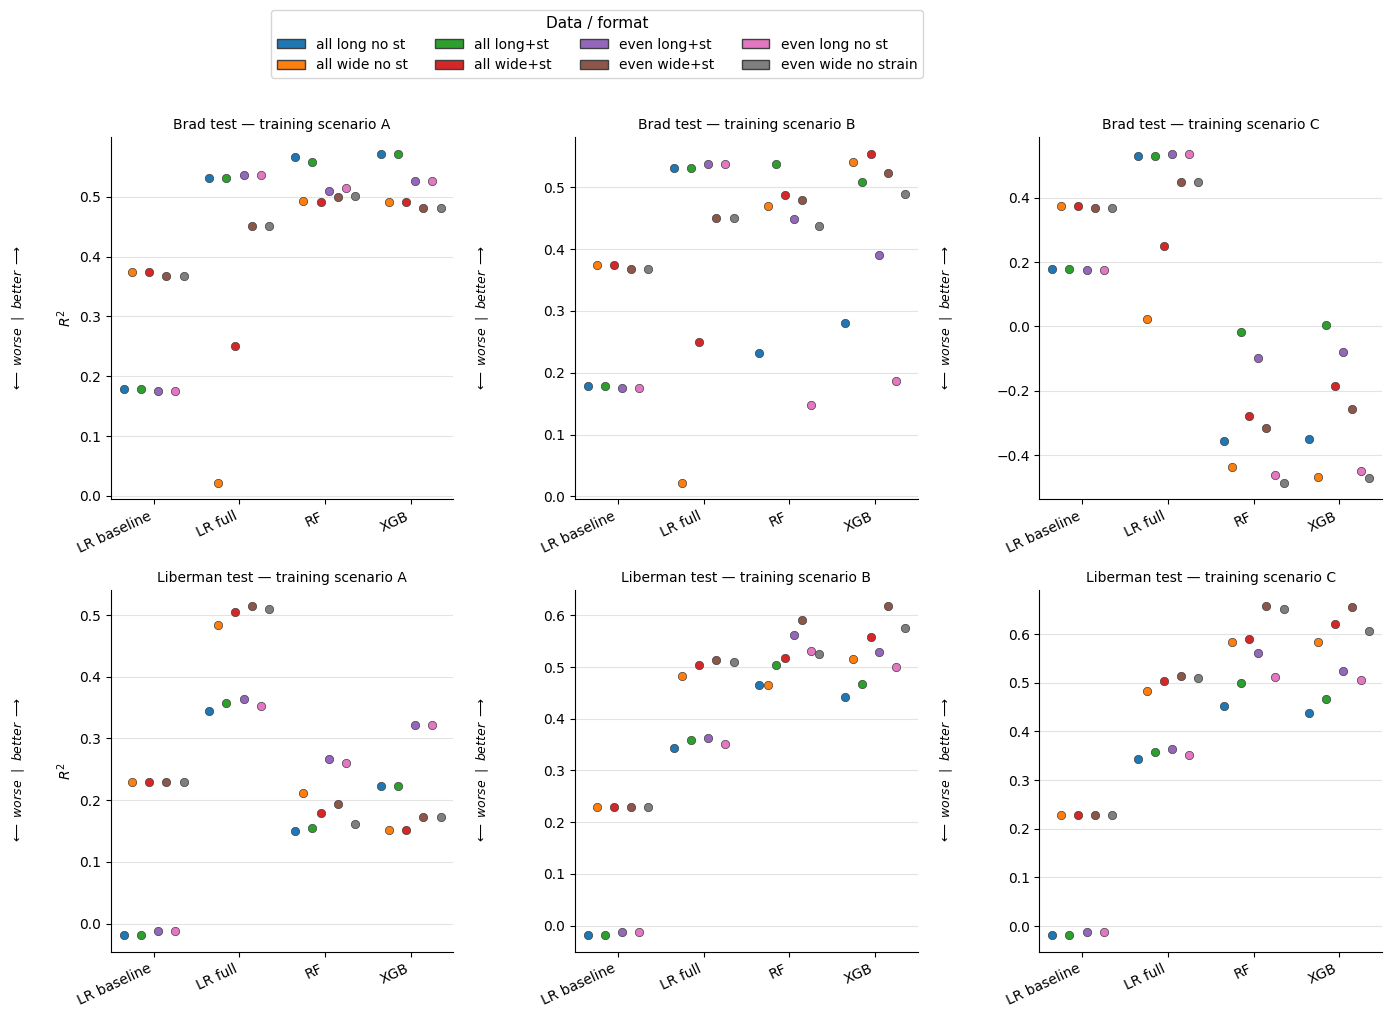

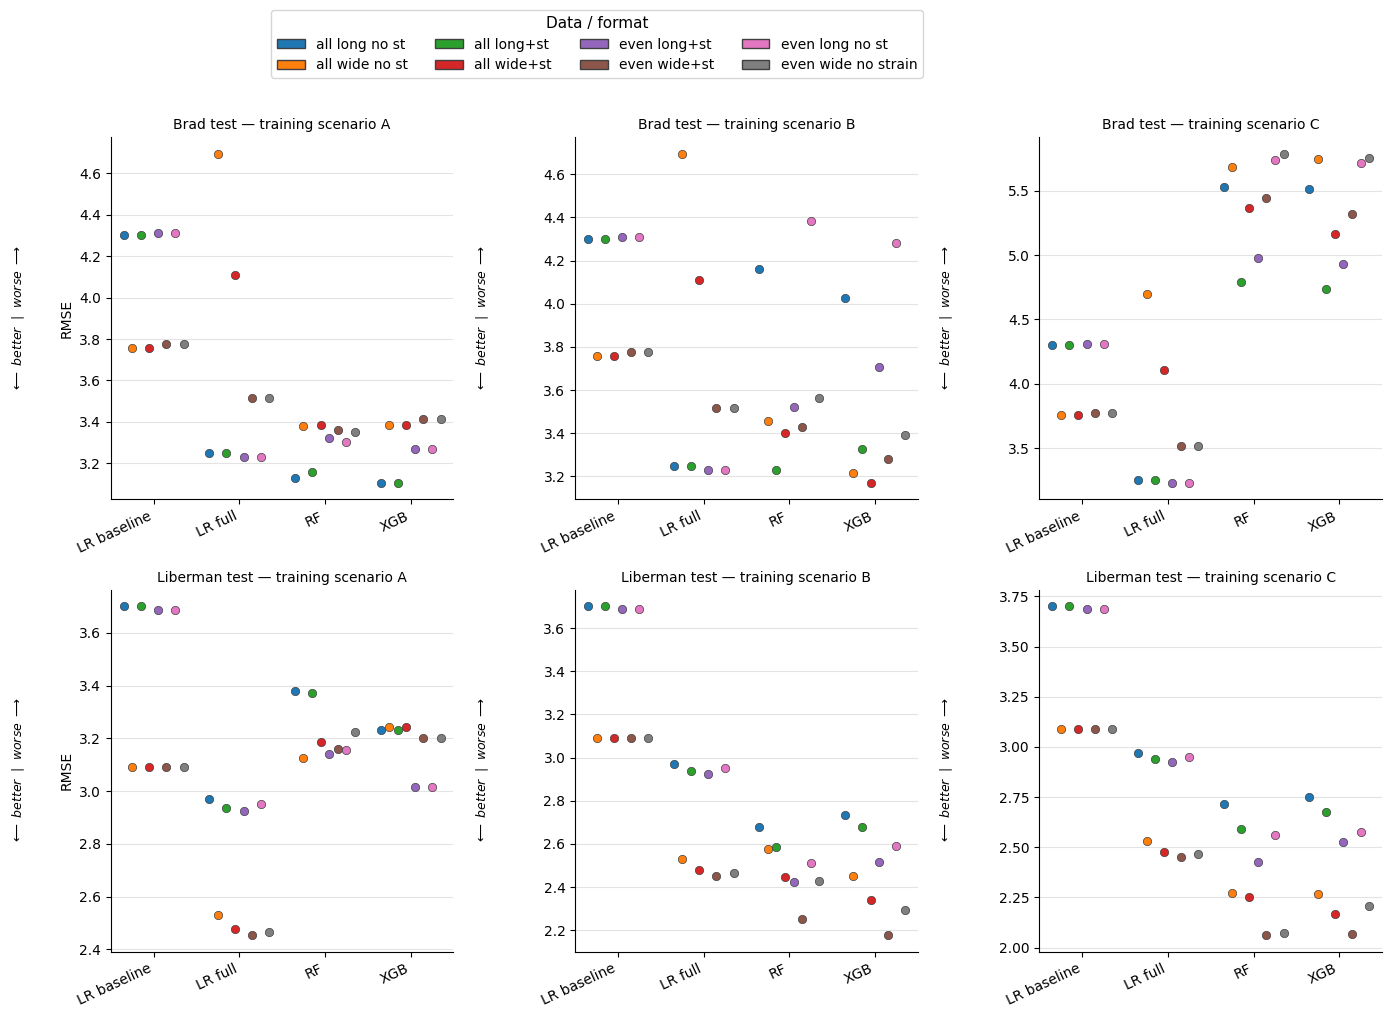

In [33]:
# Point plots — master wide vs long (requires the master comparison cell above)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch


def _wl_lookup(rows, test, scenario, model, *, long_fmt: bool, metric: str = "r2"):
    """rows: (test, scen, model, r2w, r2l, rmsew, rmsel). RF/XGB use scenario A/B/C; OLS uses '—'."""
    scen_m = scenario if model in ("RF", "XGB") else "—"
    for r in rows:
        if r[0] == test and r[1] == scen_m and r[2] == model:
            if metric == "r2":
                return float(r[4] if long_fmt else r[3])
            return float(r[6] if long_fmt else r[5])
    return float("nan")


_X_MODEL_ORDER = ["LR baseline", "LR full", "RF", "XGB"]
_MODEL_KEY = {
    "LR baseline": "OLS base",
    "LR full": "OLS full",
    "RF": "RF",
    "XGB": "XGB",
}

_VARIANT_SPECS = [
    ("all long no st", "rows1", True),
    ("all wide no st", "rows1", False),
    ("all long+st", "rows2", True),
    ("all wide+st", "rows2", False),
    ("even long+st", "rows6", True),
    ("even wide+st", "rows6", False),
    ("even long no st", "rows4", True),
    ("even wide no strain", "rows4", False),
]


def _master_metrics_long_df(metric: str) -> pd.DataFrame:
    """Long table for stripplot: one row per (test, scenario, x_model, variant)."""
    row_bundles = {"rows1": rows1, "rows4": rows4}
    try:
        row_bundles["rows2"] = rows2
    except NameError:
        pass
    try:
        row_bundles["rows6"] = rows6
    except NameError:
        pass

    recs = []
    for vlabel, rkey, use_long in _VARIANT_SPECS:
        rows = row_bundles.get(rkey)
        if rows is None:
            continue
        for test_key, test_name in (("Brad", "Brad test"), ("Lib", "Liberman test")):
            for scen in ("A", "B", "C"):
                for xm in _X_MODEL_ORDER:
                    mk = _MODEL_KEY[xm]
                    val = _wl_lookup(
                        rows, test_key, scen, mk, long_fmt=use_long, metric=metric
                    )
                    recs.append(
                        {
                            "test_set": test_name,
                            "scenario": scen,
                            "x_model": xm,
                            "variant": vlabel,
                            "value": val,
                        }
                    )
    return pd.DataFrame.from_records(recs)


def _plot_master_points(metric: str, y_label: str, better_text: str) -> None:
    df = _master_metrics_long_df(metric)
    if df.empty:
        print("No data to plot (run master cell first).")
        return

    x_order = _X_MODEL_ORDER
    present = set(df["variant"].unique())
    hue_order = [v[0] for v in _VARIANT_SPECS if v[0] in present]

    colors = sns.color_palette("tab10", n_colors=max(8, len(hue_order)))
    test_order = ["Brad test", "Liberman test"]
    scen_order = ["A", "B", "C"]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=False, sharex=False)
    for row, tname in enumerate(test_order):
        for col, scen in enumerate(scen_order):
            ax = axes[row, col]
            sub = df[(df["test_set"] == tname) & (df["scenario"] == scen)]
            sns.stripplot(
                data=sub,
                x="x_model",
                y="value",
                order=x_order,
                hue="variant",
                hue_order=hue_order,
                palette=colors[: len(hue_order)],
                dodge=True,
                jitter=0.12,
                size=6,
                linewidth=0.5,
                edgecolor="0.25",
                ax=ax,
            )
            ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
            ax.set_xlabel(None)
            ax.set_title(f"{tname} — training scenario {scen}", fontsize=10)
            ax.grid(True, axis="y", alpha=0.35)
            sns.despine(ax=ax, top=True, right=True)
            if col == 0:
                ax.set_ylabel(y_label)
            else:
                ax.set_ylabel("")
            ax.text(
                -0.27,
                0.5,
                better_text,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=9,
                style="italic",
                clip_on=False,
            )
    handles = [
        Patch(facecolor=colors[i], edgecolor="0.25", label=h)
        for i, h in enumerate(hue_order)
    ]
    for ax in axes.ravel():
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    fig.legend(
        handles=handles,
        labels=hue_order,
        title="Data / format",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        fontsize=10,
        title_fontsize=11,
    )
    fig.tight_layout(rect=[0.12, 0, 1, 0.92])
    plt.show()


_plot_master_points(
    "r2",
    r"$R^2$",
    r"$\longleftarrow$ worse $\mid$ better $\longrightarrow$",
)
_plot_master_points(
    "rmse",
    "RMSE",
    r"$\longleftarrow$ better $\mid$ worse $\longrightarrow$",
)


## Export classical benchmark rows for slide figures

Run after **master comparison** rows are populated (`rows1`; with strain also `rows2`, `rows6`). Writes **`figures/cache/classical_benchmark_long.parquet`** with **variant** columns (Brad: all-long / all-wide; Liberman: all-long / all-wide / even-long / even-wide) for `presentation_benchmarks.ipynb`.

If you see **`ImportError: classical_variants_to_dataframe`**, confirm `utils/benchmark_metrics.py` is updated on disk, then **restart the kernel** or re-run this cell (it **`reload`s** the util so edits apply without restart).


In [34]:
from pathlib import Path

import importlib

from utils import benchmark_metrics as _bm_metrics

importlib.reload(_bm_metrics)
classical_variants_to_dataframe = _bm_metrics.classical_variants_to_dataframe

_cache = Path("figures/cache")
_cache.mkdir(parents=True, exist_ok=True)
out = _cache / "classical_benchmark_long.parquet"
if _HAS_STRAIN:
    cdf = classical_variants_to_dataframe(rows1, rows2, rows6)
else:
    cdf = classical_variants_to_dataframe(rows1)
cdf.to_parquet(out)
print("Saved", out.resolve())


Saved /Users/nowaki027/MSDS/Practicum/figures/cache/classical_benchmark_long.parquet


In [ ]:
import importlib
import utils.nn_stage2_data
importlib.reload(utils.nn_stage2_data)

from utils.nn_stage2_data import load_nn_stage2_data, splits_for_long_stage2

_data_chk = load_nn_stage2_data()
_sp_chk = splits_for_long_stage2(_data_chk)
_bb_test_chk = set(_sp_chk["bb_wide_test"]["animal_id"])
assert _bb_test_chk == set(_bb_test_animals), (
    "Brad test animals differ from load_nn_stage2_data"
)
print("Parity OK: Brad test animals match utils loader")
